# STAR-RIS RSMA Networks - DRL Resource Allocation
## Notebook Huấn luyện & Đánh giá (12 Seeds)

Notebook này chứa toàn bộ pipeline từ thiết lập môi trường, tải cấu hình, chạy huấn luyện đa seed (12 seeds) cho các thuật toán MADDPG, DDPG, TD3, PPO, đánh giá hiệu năng (evaluation), nghiên cứu loại bỏ (ablation study), vẽ đồ thị hội tụ, và thống kê kết quả.

**Lưu ý khi chạy trên Kaggle GPU:**
- Bật GPU trong phần Accelerator (chọn GPU T4 x2 hoặc GPU P100).
- Bộ mã nguồn được tối ưu hóa tự động chuyển sang thiết bị CUDA nếu có GPU khả dụng.

### 1. Kiểm tra phần cứng và Cài đặt thư viện cần thiết
Cell này kiểm tra xem GPU/CUDA có khả dụng hay không, đồng thời tiến hành cài đặt các thư viện cần thiết cho dự án.

In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# Cài đặt các thư viện bổ sung nếu cần thiết (đặc biệt khi chạy trên Kaggle)
!pip install gymnasium pyyaml tqdm pandas matplotlib tensorboard

PyTorch Version: 2.10.0+cu128
CUDA Available: True
Device Name: Tesla T4


### 2. Thiết lập đường dẫn dự án và Import thư viện
Thêm thư mục gốc của dự án vào `sys.path` để notebook có thể import đúng các module nội bộ (`env`, `algorithms`, `utils`, `experiments`).

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

# Thiết lập thư mục gốc của dự án
PROJECT_ROOT = "/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import các hàm từ module của dự án
from experiments.train import (
    train_maddpg, train_single_agent, train_ppo, evaluate_agent, _make_env,
)
from experiments.evaluate import (
    sweep_power, qos_satisfaction, latency_benchmark,
    _eval_multi_seed,
)
from experiments.ablation import ablation_study, ABLATION_CELLS
from utils.plotting import (
    plot_training_convergence, plot_metric_vs_x, plot_bar,
    plot_reward_decomposition, plot_qos_lambda,
    plot_phase_histogram, plot_h_eff_distribution, plot_pareto,
)
from utils import welch_ttest_p, confidence_interval

print("Import thành công tất cả thư viện và module!")

2026-06-12 02:32:24.819947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781231544.995712      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781231545.045767      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781231545.462396      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781231545.462439      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781231545.462442      23 computation_placer.cc:177] computation placer alr

Import thành công tất cả thư viện và module!


### 3. Tải và Hiển thị Cấu hình (Configuration)
Đọc cấu hình hệ thống từ `config/config.yaml`. Nâng cấp danh sách seed huấn luyện (`training_seeds`) lên 12 seeds.

In [3]:
config_path = os.path.join(PROJECT_ROOT, "config", "config.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

print("Cấu hình hệ thống:")
print(f"- Số lượng STAR-RIS elements (N): {cfg['env']['num_ris_elements']}")
print(f"- Số lượng Users (K): {cfg['env']['num_users']}")
print(f"- Thiết bị chạy (device): {cfg['device']} (Tự động chọn CUDA nếu có)")
print(f"- Danh sách training seeds (12 seeds): {cfg['training']['training_seeds']}")
print(f"- Số episodes huấn luyện mỗi seed: {cfg['training']['total_episodes']}")

Cấu hình hệ thống:
- Số lượng STAR-RIS elements (N): 32
- Số lượng Users (K): 4
- Thiết bị chạy (device): auto (Tự động chọn CUDA nếu có)
- Danh sách training seeds (12 seeds): [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
- Số episodes huấn luyện mỗi seed: 1000


### 4. Huấn luyện các Thuật toán với 12 Seeds
Chúng ta sẽ thực hiện huấn luyện các thuật toán: `MADDPG`, `DDPG`, `TD3`, `PPO` trên từng seed trong danh sách 12 seeds. Lịch sử huấn luyện (history) của từng seed sẽ được lưu trữ để phục vụ cho việc vẽ đồ thị hội tụ và tính khoảng tin cậy.

**Lưu ý:** Tiến độ huấn luyện sẽ được in ra trực tiếp dưới dạng log của tqdm.

In [4]:
# Thiết lập thư mục đầu ra cho log và checkpoint
out_root = "/kaggle/working/"
fig_dir = os.path.join(out_root, "figures")
tab_dir = os.path.join(out_root, "tables")
log_dir = os.path.join(out_root, cfg["training"]["log_dir"])
ckpt_dir = os.path.join(out_root, cfg["training"]["ckpt_dir"])
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tab_dir, exist_ok=True)

def _save_history_csv(path: str, history: dict):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame({k: v for k, v in history.items() if hasattr(v, "__len__")})
    df.to_csv(path, index=False)

training_seeds = list(cfg["training"].get("training_seeds"))
algos_to_train = ["maddpg", "ddpg", "td3", "ppo"]
trained = {}

algo_train_fns = {
    "maddpg": ("MADDPG", lambda s, **kw: train_maddpg(
        cfg, log_dir=log_dir, ckpt_dir=ckpt_dir, seed_override=s,
        run_name=f"maddpg_seed{s}", **kw)),
    "ddpg":   ("DDPG", lambda s, **kw: train_single_agent(
        cfg, kind="ddpg", log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"ddpg_seed{s}", **kw)),
    "td3":    ("TD3", lambda s, **kw: train_single_agent(
        cfg, kind="td3", log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"td3_seed{s}", **kw)),
    "ppo":    ("PPO", lambda s, **kw: train_ppo(
        cfg, log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"ppo_seed{s}", **kw)),
}

for algo_key in algos_to_train:
    if algo_key not in algo_train_fns:
        continue
    label, fn = algo_train_fns[algo_key]
    trained[label] = []
    for s in training_seeds:
        print(f"\n========== ĐANG HUẤN LUYỆN {label} (Seed={s}) ==========")
        info = fn(s)
        _save_history_csv(os.path.join(log_dir, f"{label}_seed{s}", "history.csv"),
                          info["history"])
        trained[label].append(info)

# trained_main: lấy kết quả của seed đầu tiên phục vụ cho vẽ đồ thị đặc trưng / ablation study
trained_main = {algo: runs[0] for algo, runs in trained.items()}
print("\nHuấn luyện thành công toàn bộ 12 seeds!")


========== ĐANG HUẤN LUYỆN MADDPG (Seed=1000) ==========


maddpg_seed1000:   9%| | 90/1000 [00:06<00:51, 17.50it/s, ret=-1.64, MA=-0.41, qos=0.02, λ=14.73, |h_T|=3.43e-/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.1714 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed1000:   9%| | 92/1000 [00:06<00:51, 17.59it/s, ret=-1.18, MA=-0.48, qos=0.08, λ=15.00, |h_T|=4.46e-/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.4500 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed1000:  54%|▌| 540/1000 [09:23<09:41,  1.26s/it, ret=-1.12, MA=2.22, qos=0.00, λ=14.93, |h_T|=1.87e-/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning


========== ĐANG HUẤN LUYỆN MADDPG (Seed=2000) ==========


maddpg_seed2000:  56%|▌| 556/1000 [09:57<09:25,  1.27s/it, ret=0.77, MA=2.50, qos=0.24, λ=14.72, |h_T|=4.14e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.1583 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed2000:  63%|▋| 633/1000 [11:36<07:39,  1.25s/it, ret=0.56, MA=2.60, qos=0.10, λ=14.89, |h_T|=1.99e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.3391 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed2000: 100%|█| 1000/1000 [19:34<00:00,  1.17s/it, ret=3.98, MA=3.61, qos=0.96, λ=1.19, |h_T|=5.59e-0



========== ĐANG HUẤN LUYỆN MADDPG (Seed=3000) ==========


...


========== ĐANG HUẤN LUYỆN PPO (Seed=11000) ==========


ppo_seed11000: 100%|████████████████| 1000/1000 [02:21<00:00,  7.09it/s, ret=1.84, MA=1.38, qos=0.38, λ=15.00]



========== ĐANG HUẤN LUYỆN PPO (Seed=12000) ==========


ppo_seed12000: 100%|████████████████| 1000/1000 [02:21<00:00,  7.05it/s, ret=1.46, MA=0.88, qos=0.16, λ=15.00]


Huấn luyện thành công toàn bộ 12 seeds!


### 5. Vẽ Đồ thị Hội tụ Huấn luyện (Training Convergence Curves)
Cell này tổng hợp lịch sử huấn luyện trên toàn bộ 12 seeds để tính trung bình và vẽ đồ thị hội tụ với dải lệch chuẩn cho các chỉ số:
- **Episode return**: Tổng phần thưởng tích lũy trung bình.
- **Avg. sum-rate**: Tốc độ truyền tổng cộng trung bình (b/s/Hz).
- **QoS satisfaction**: Xác suất đáp ứng yêu cầu QoS tối thiểu của người dùng.
- **Common power fraction**: Tỷ lệ công suất phân bổ cho dòng tin chung ($P_c/P_{\max}$).

Hình ảnh kết quả sẽ được hiển thị trực tiếp ngay dưới cell chạy.


========== Đang tổng hợp và vẽ đồ thị hội tụ (Đa Seed) ==========
--- Đồ thị hội tụ (Return) ---


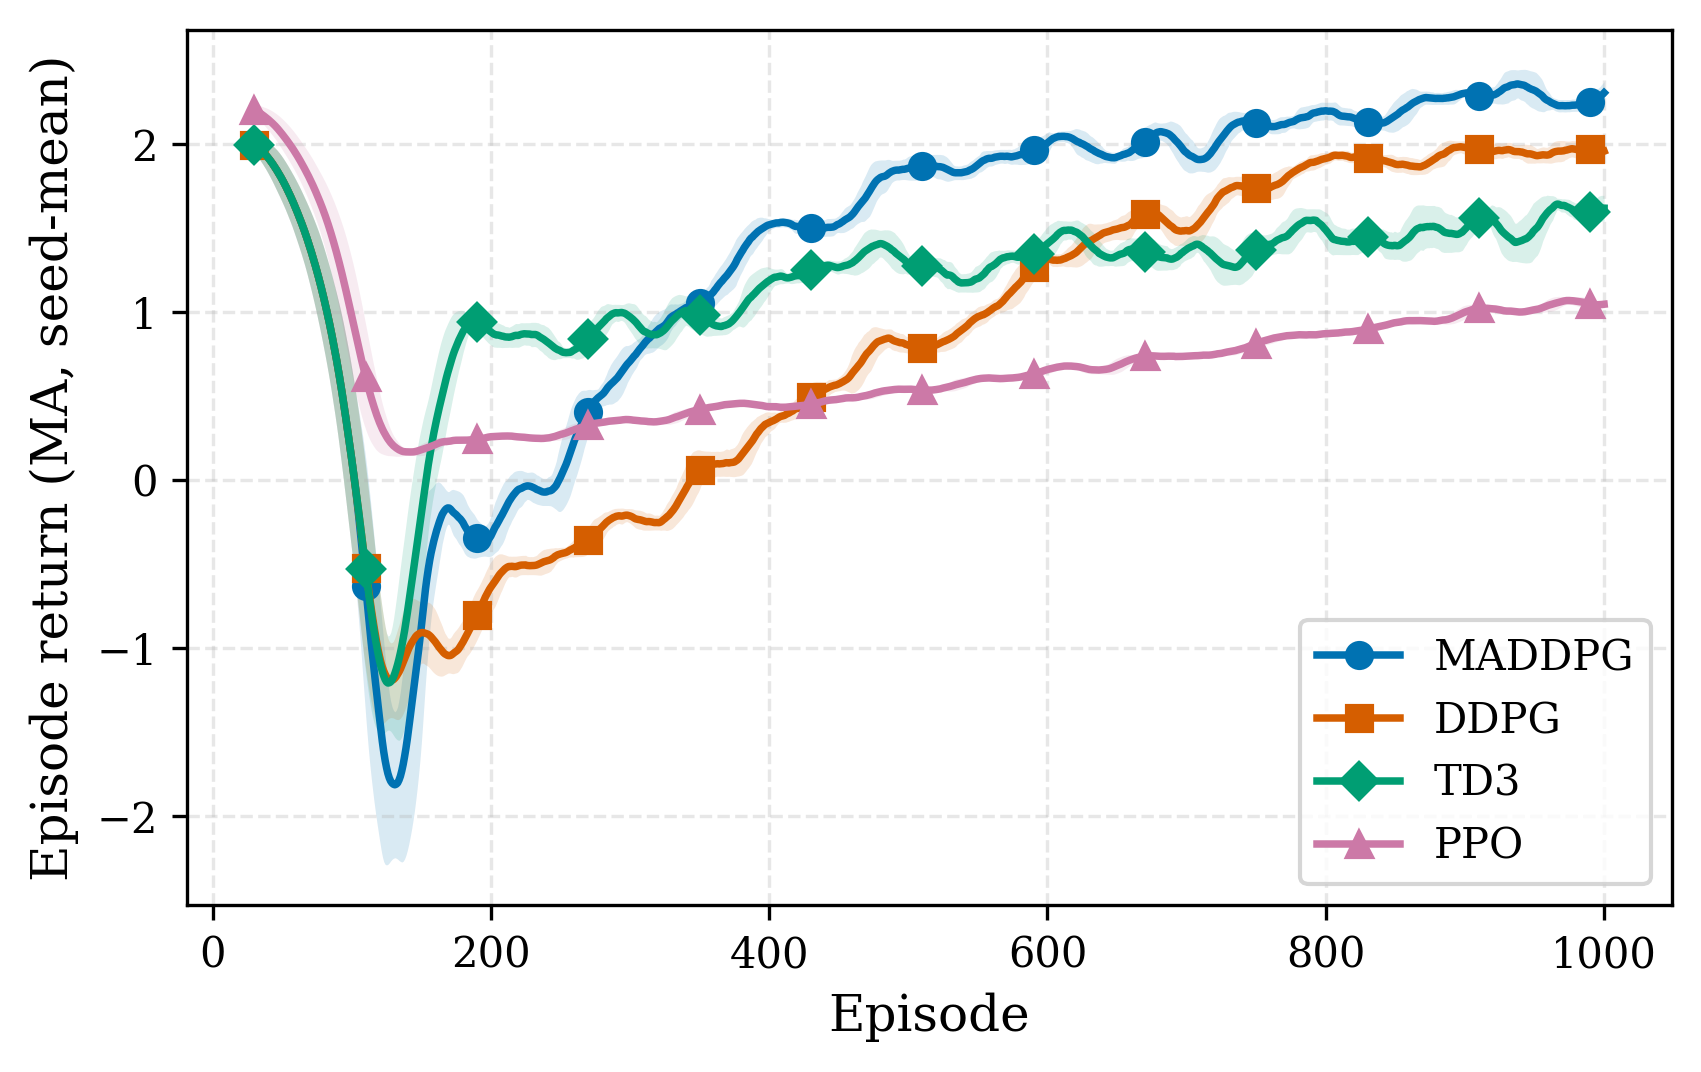

--- Đồ thị Sum-rate trung bình ---


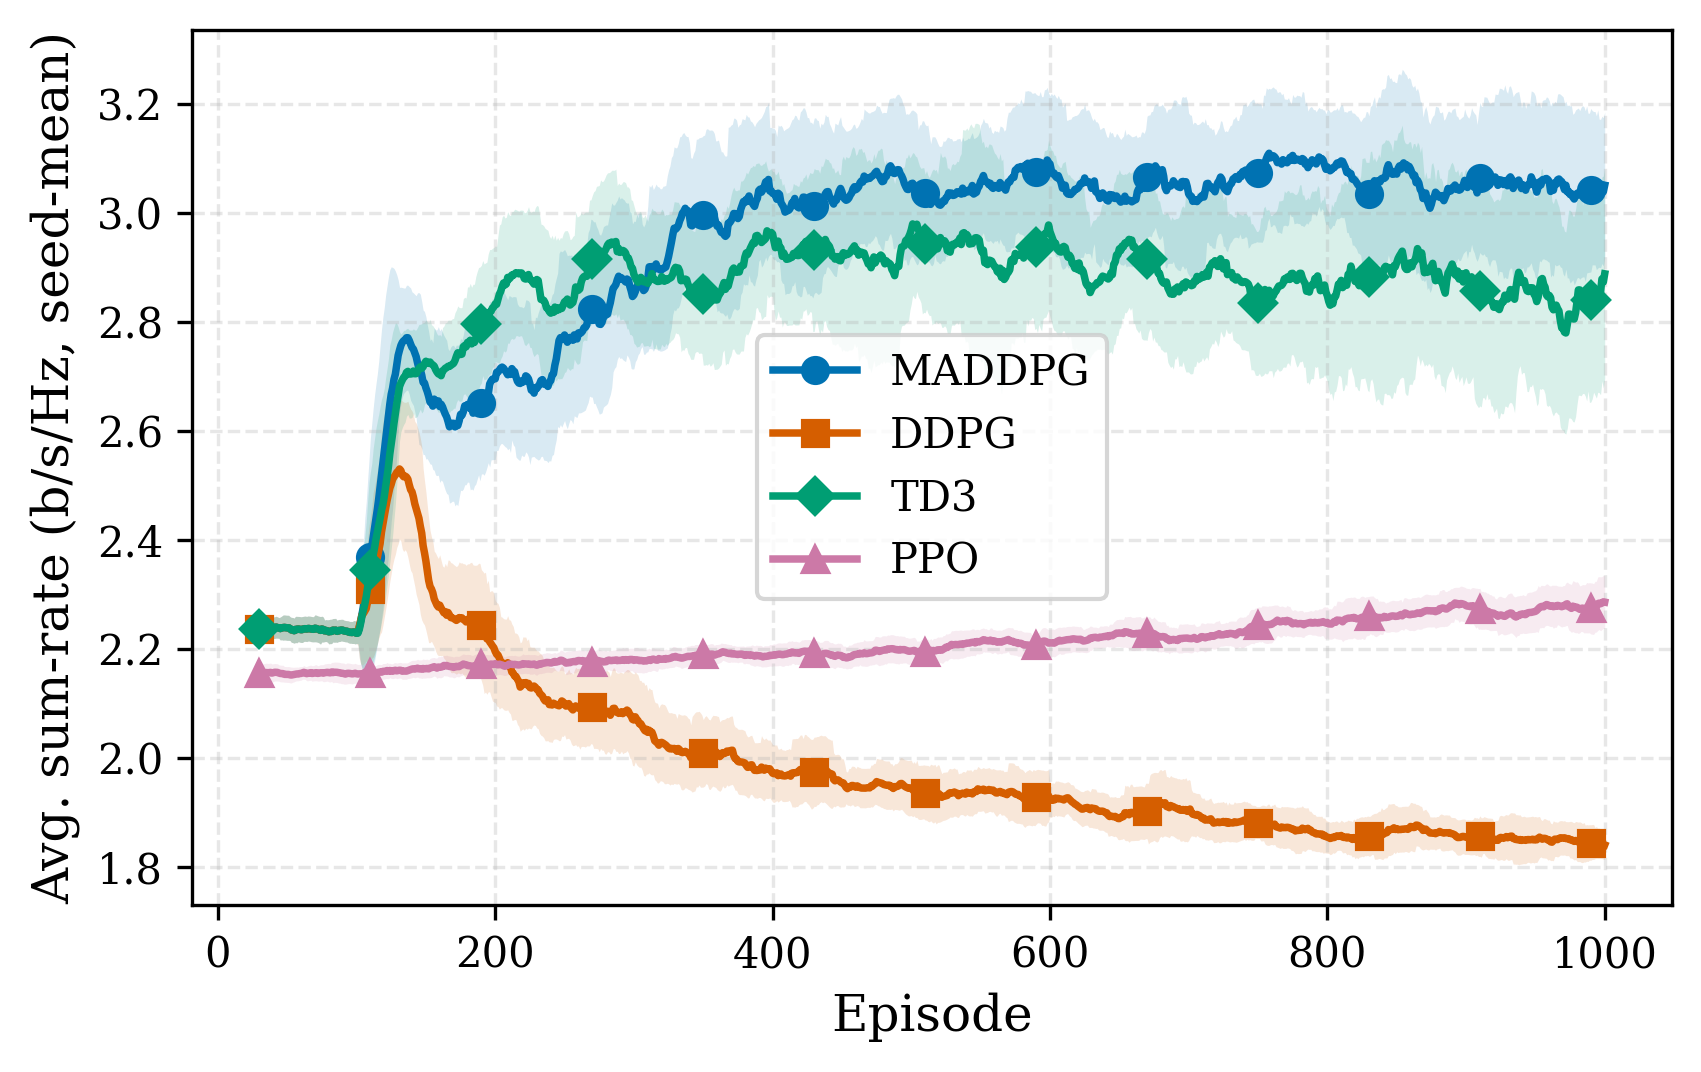

--- Đồ thị QoS Satisfaction ---


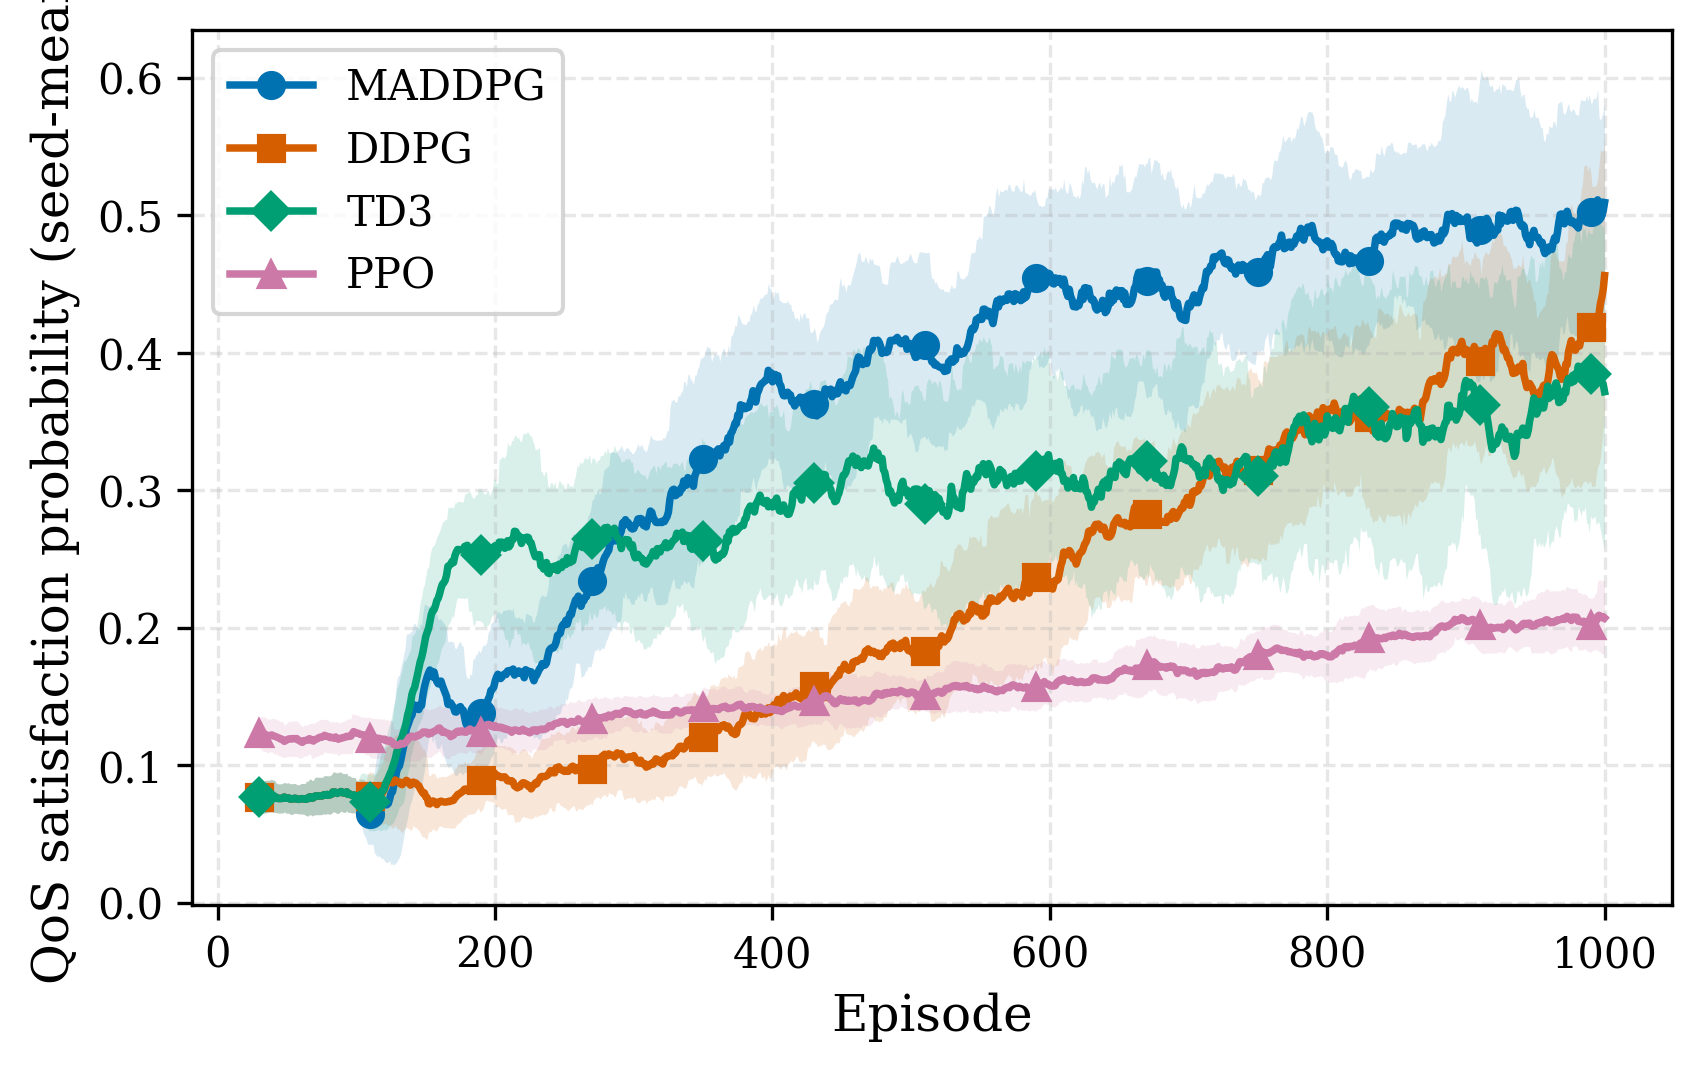

--- Đồ thị Tỷ lệ công suất dòng tin chung (P_c / P_max) ---


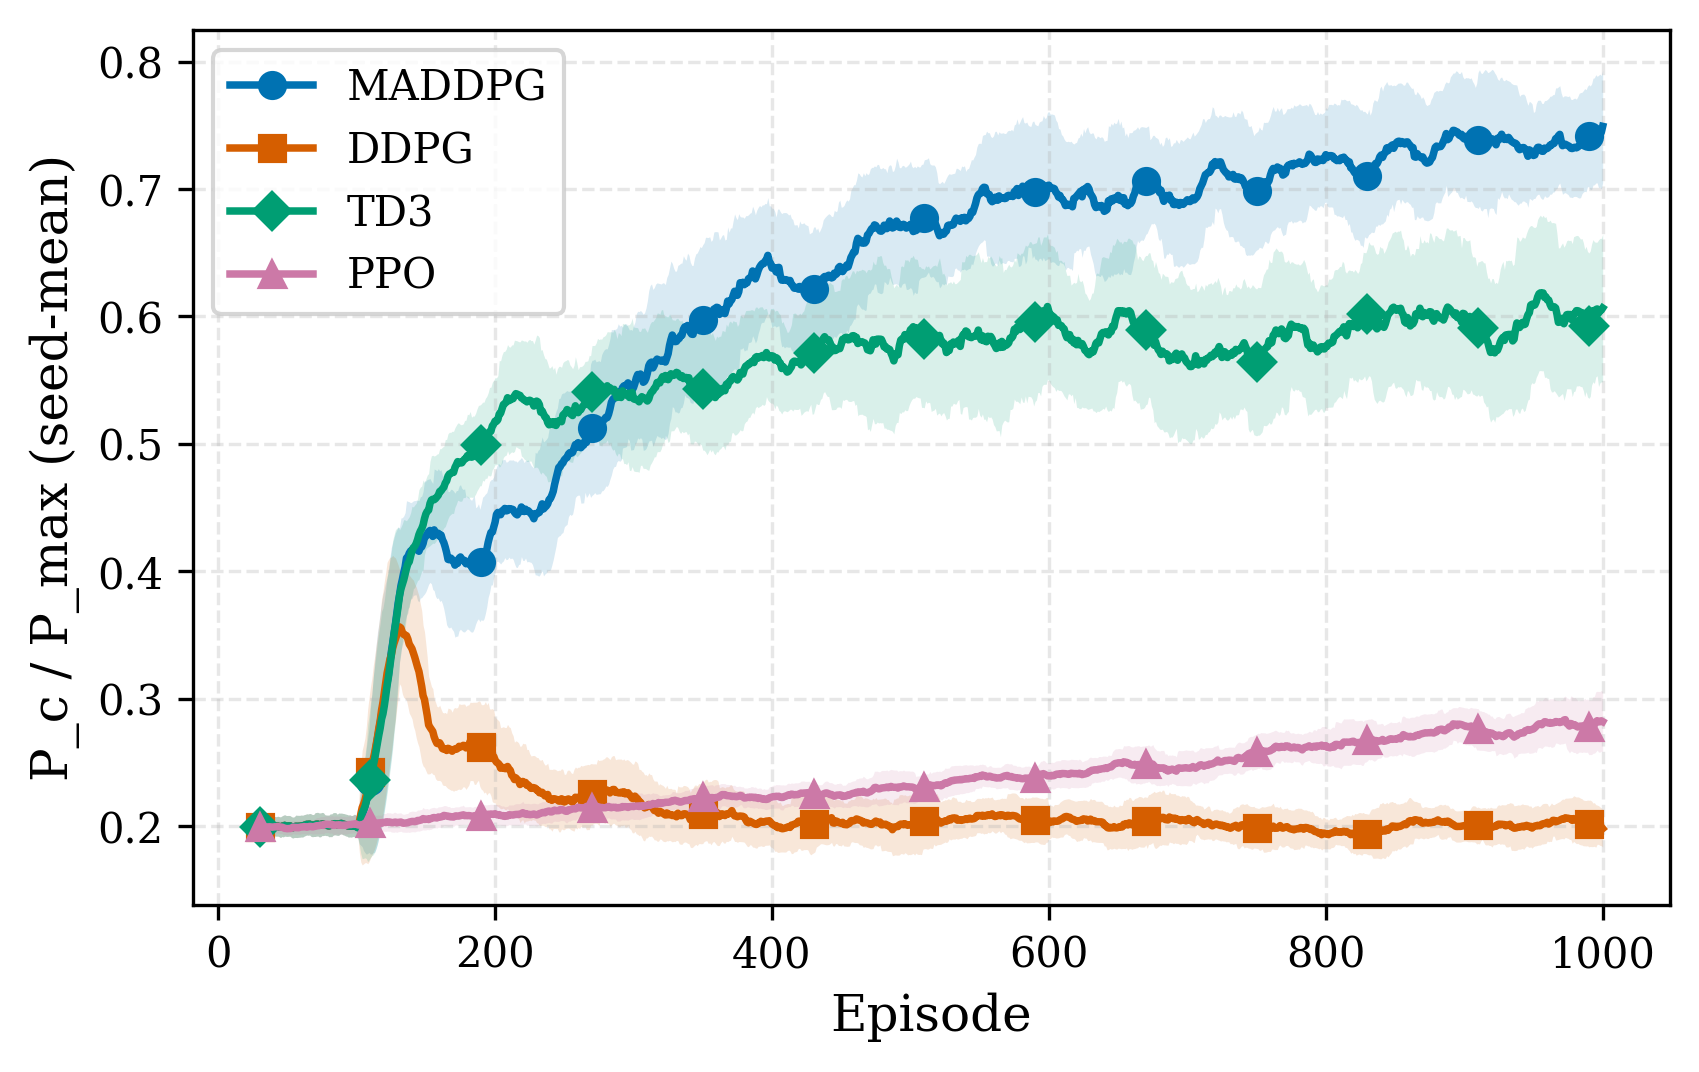

In [5]:
print("\n========== Đang tổng hợp và vẽ đồ thị hội tụ (Đa Seed) ==========")
def _seeds_curve(metric: str) -> dict[str, np.ndarray]:
    out = {}
    for algo, runs in trained.items():
        mat = []
        for info in runs:
            v = np.array(info["history"][metric], dtype=float)
            mat.append(v)
        min_len = min(len(v) for v in mat)
        mat = np.stack([v[:min_len] for v in mat], axis=0)   # (n_seeds, T)
        out[algo] = mat.mean(axis=0)
    return out

plot_training_convergence(_seeds_curve("ma_return"), out_dir=fig_dir,
                          name="training_convergence",
                          ylabel="Episode return (MA, seed-mean)")
plot_training_convergence(_seeds_curve("sum_rate"), out_dir=fig_dir,
                          name="training_sum_rate",
                          ylabel="Avg. sum-rate (b/s/Hz, seed-mean)")
plot_training_convergence(_seeds_curve("qos_satisfied"), out_dir=fig_dir,
                          name="training_qos_prob",
                          ylabel="QoS satisfaction probability (seed-mean)")
plot_training_convergence(_seeds_curve("common_power_frac"), out_dir=fig_dir,
                          name="training_common_power_frac",
                          ylabel="P_c / P_max (seed-mean)")

# Hiển thị ảnh trực tiếp
print("--- Đồ thị hội tụ (Return) ---")
display(Image(filename=os.path.join(fig_dir, "training_convergence.png")))
print("--- Đồ thị Sum-rate trung bình ---")
display(Image(filename=os.path.join(fig_dir, "training_sum_rate.png")))
print("--- Đồ thị QoS Satisfaction ---")
display(Image(filename=os.path.join(fig_dir, "training_qos_prob.png")))
print("--- Đồ thị Tỷ lệ công suất dòng tin chung (P_c / P_max) ---")
display(Image(filename=os.path.join(fig_dir, "training_common_power_frac.png")))

### 6. Phân tích Adaptive QoS Lambda và Phân rã Phần thưởng (Reward Decomposition)
Phân tích cách tham số Lagrangian $\lambda$ thích ứng trong quá trình huấn luyện của thuật toán MADDPG để đảm bảo tính ràng buộc QoS. Đồng thời phân rã phần thưởng thành các thành phần (Sum-rate, QoS, Power penalty) để kiểm chứng cơ chế học tập của agent.


========== Vẽ đồ thị adaptive λ và phân rã reward cho MADDPG ==========
--- Adaptive QoS Lambda ---


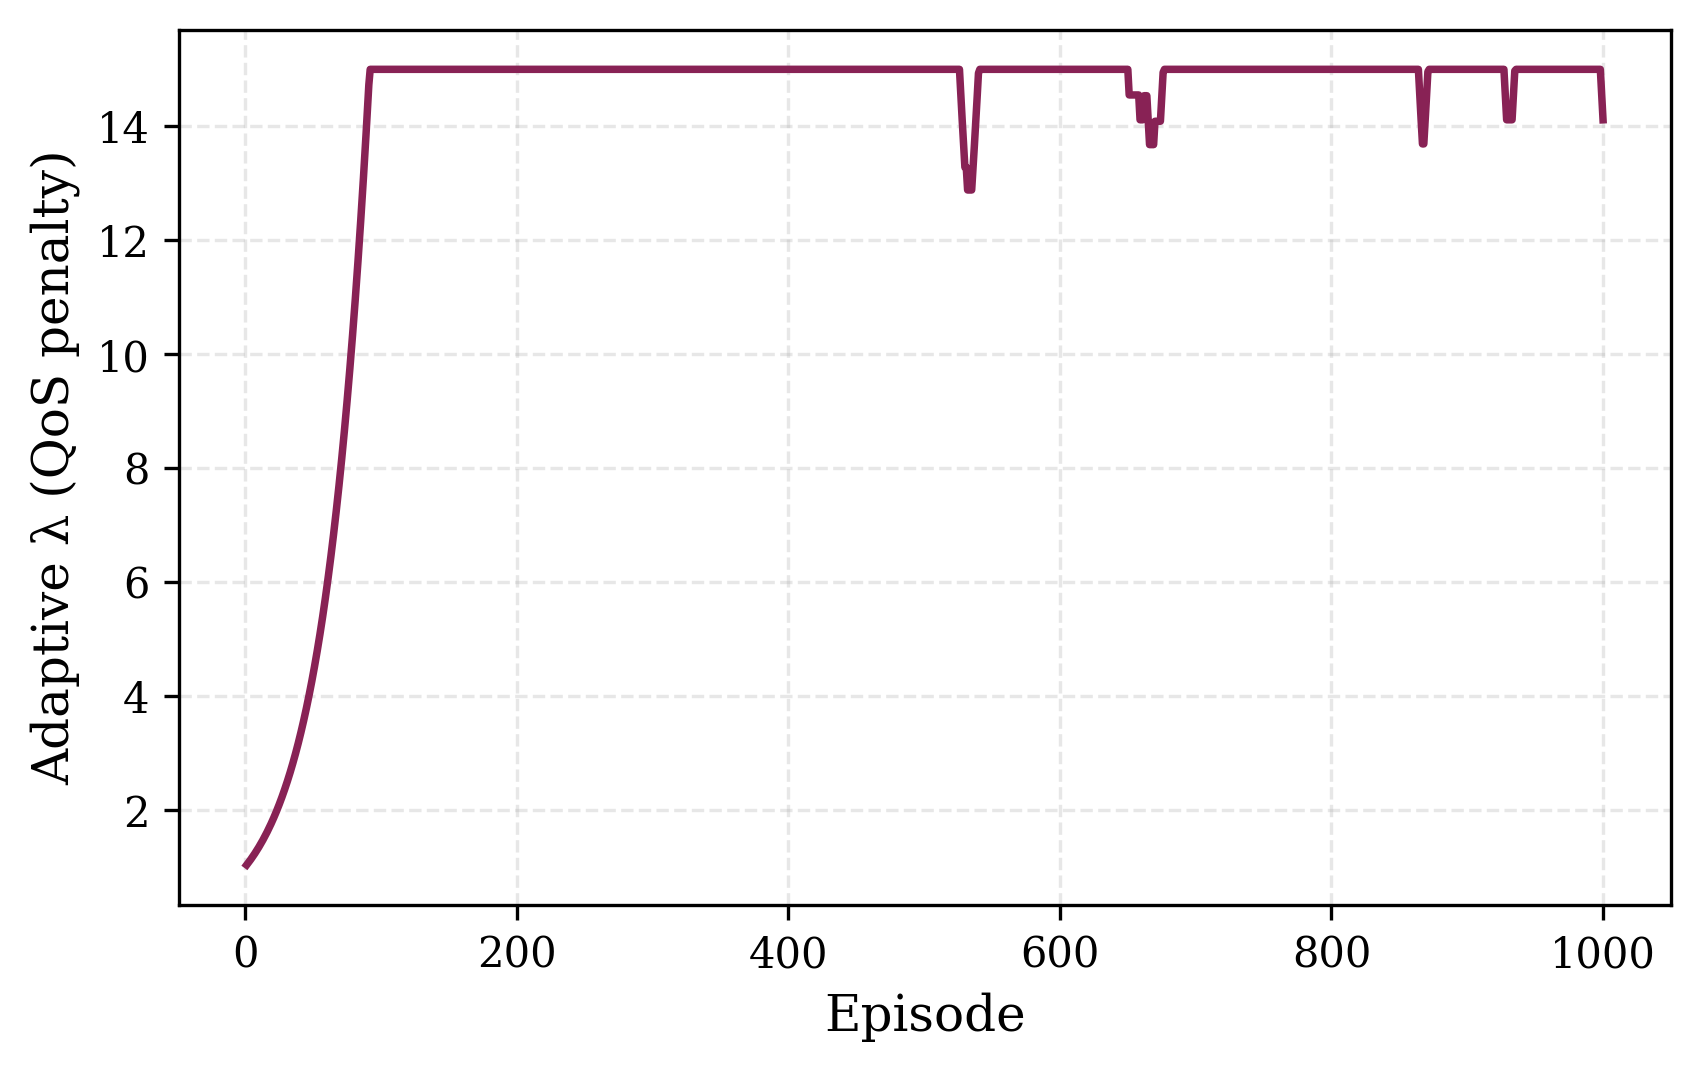

--- Phân rã phần thưởng (Reward Decomposition) ---


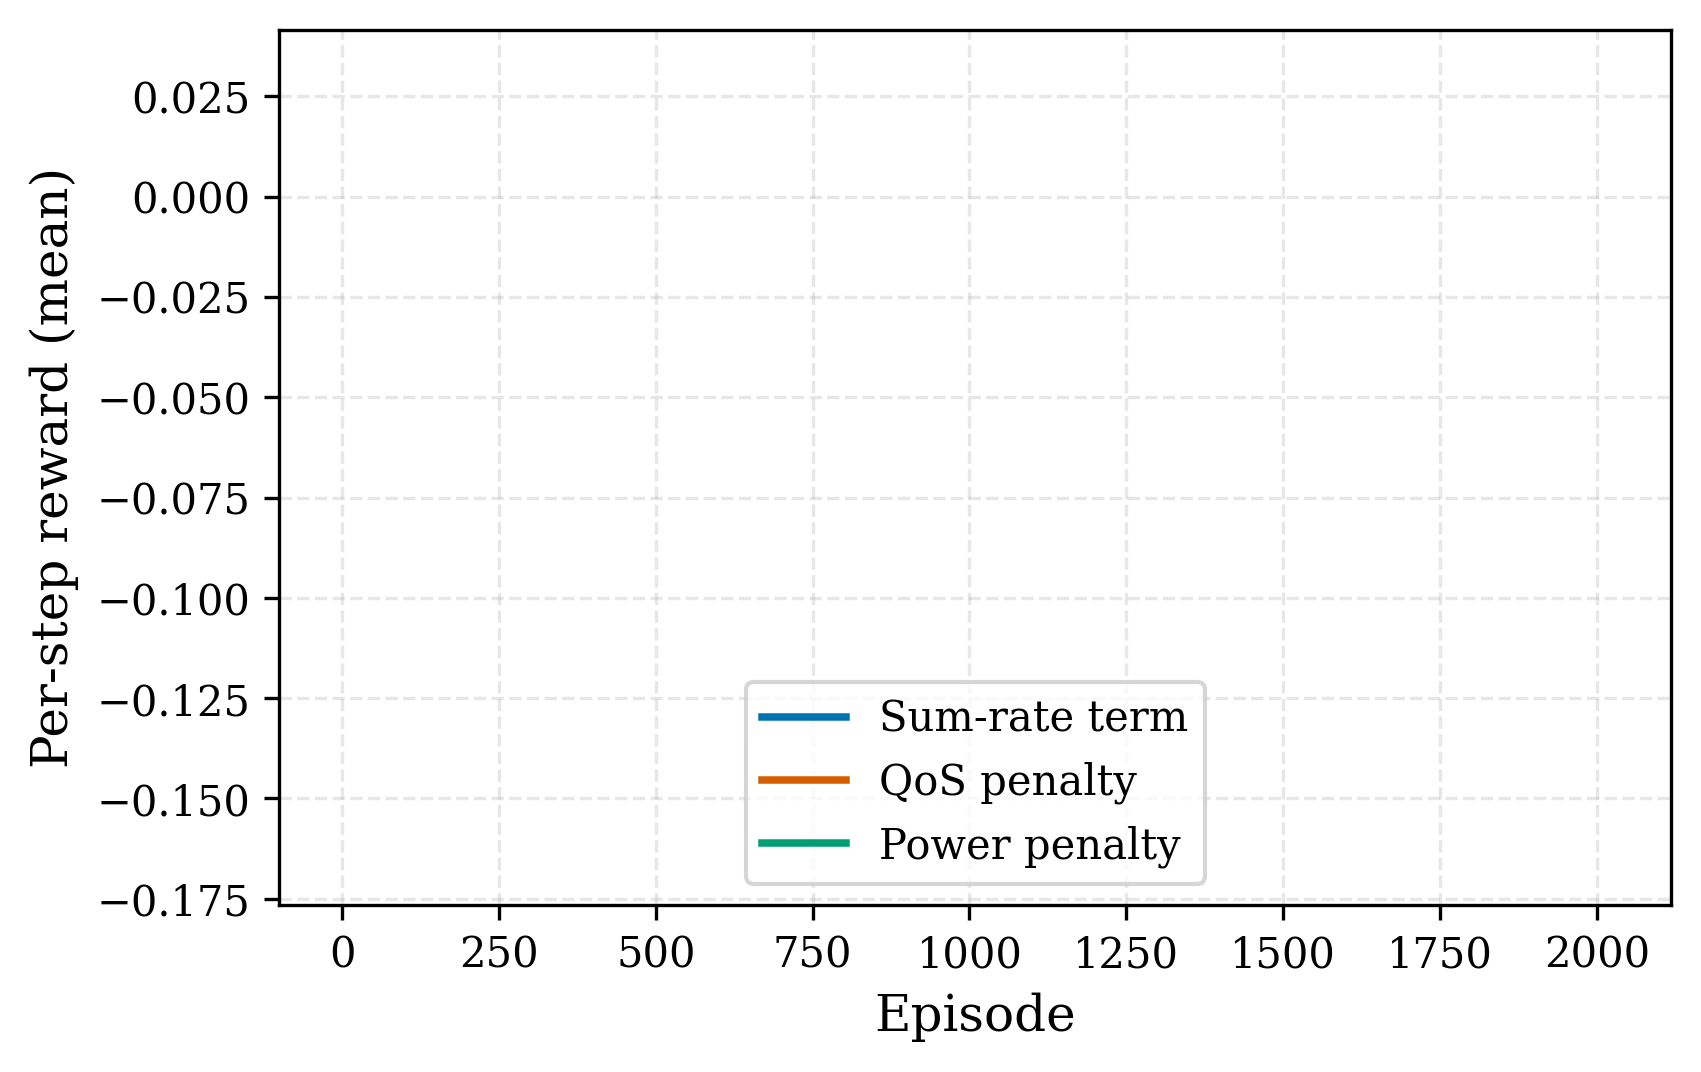

In [6]:
if "MADDPG" in trained:
    print("\n========== Vẽ đồ thị adaptive λ và phân rã reward cho MADDPG ==========")
    plot_qos_lambda(trained_main["MADDPG"]["history"], out_dir=fig_dir, name="qos_lambda")
    first_seed = training_seeds[0]
    log_csv = os.path.join(log_dir, f"maddpg_seed{first_seed}", "log.csv")
    if not os.path.exists(log_csv):
        log_csv = os.path.join(log_dir, f"MADDPG_seed{first_seed}", "log.csv")
    
    if os.path.exists(log_csv):
        df_log = pd.read_csv(log_csv)
        dec = {
            "reward_sr_mean":  df_log["reward_sr_mean"].values if "reward_sr_mean" in df_log else [],
            "reward_qos_mean": df_log["reward_qos_mean"].values if "reward_qos_mean" in df_log else [],
            "reward_pwr_mean": df_log["reward_pwr_mean"].values if "reward_pwr_mean" in df_log else [],
        }
        plot_reward_decomposition(dec, out_dir=fig_dir, name="reward_decomposition")
        
    # Hiển thị ảnh trực tiếp
    print("--- Adaptive QoS Lambda ---")
    display(Image(filename=os.path.join(fig_dir, "qos_lambda.png")))
    if os.path.exists(os.path.join(fig_dir, "reward_decomposition.png")):
        print("--- Phân rã phần thưởng (Reward Decomposition) ---")
        display(Image(filename=os.path.join(fig_dir, "reward_decomposition.png")))
else:
    print("MADDPG không được huấn luyện, bỏ qua cell này.")

### 7. Đánh giá độ nhạy (Sweeps): Tốc độ truyền tổng cộng & Xác suất QoS theo Công suất BS ($P_{\max}$)
Chúng ta quét công suất phát cực đại $P_{\max}$ tại BS từ 10 dBm đến 35 dBm để so sánh khả năng tối ưu tài nguyên của các thuật toán RL khác nhau trong các điều kiện ngân sách công suất khác nhau.


========== Sweep: Sum-rate & QoS vs Pmax (Đa Seed CI) ==========
--- Đồ thị Sum-rate vs BS Transmit Power ---


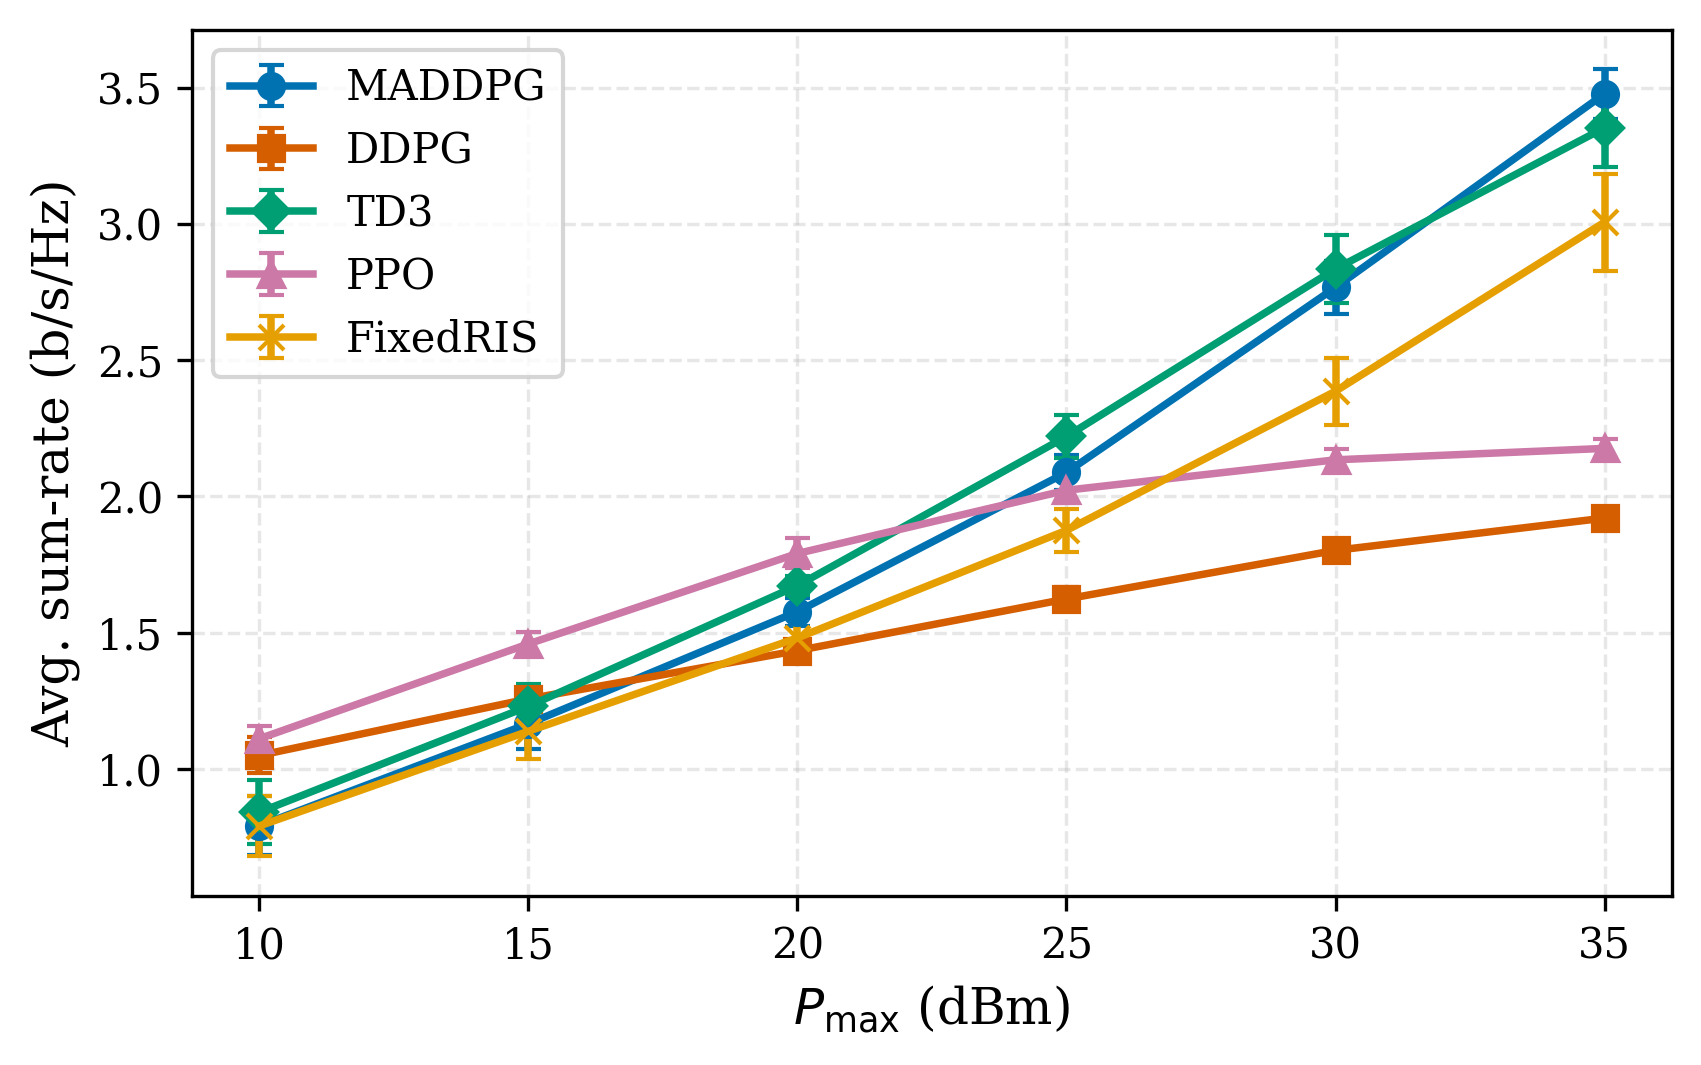

--- Đồ thị QoS Satisfaction vs BS Transmit Power ---


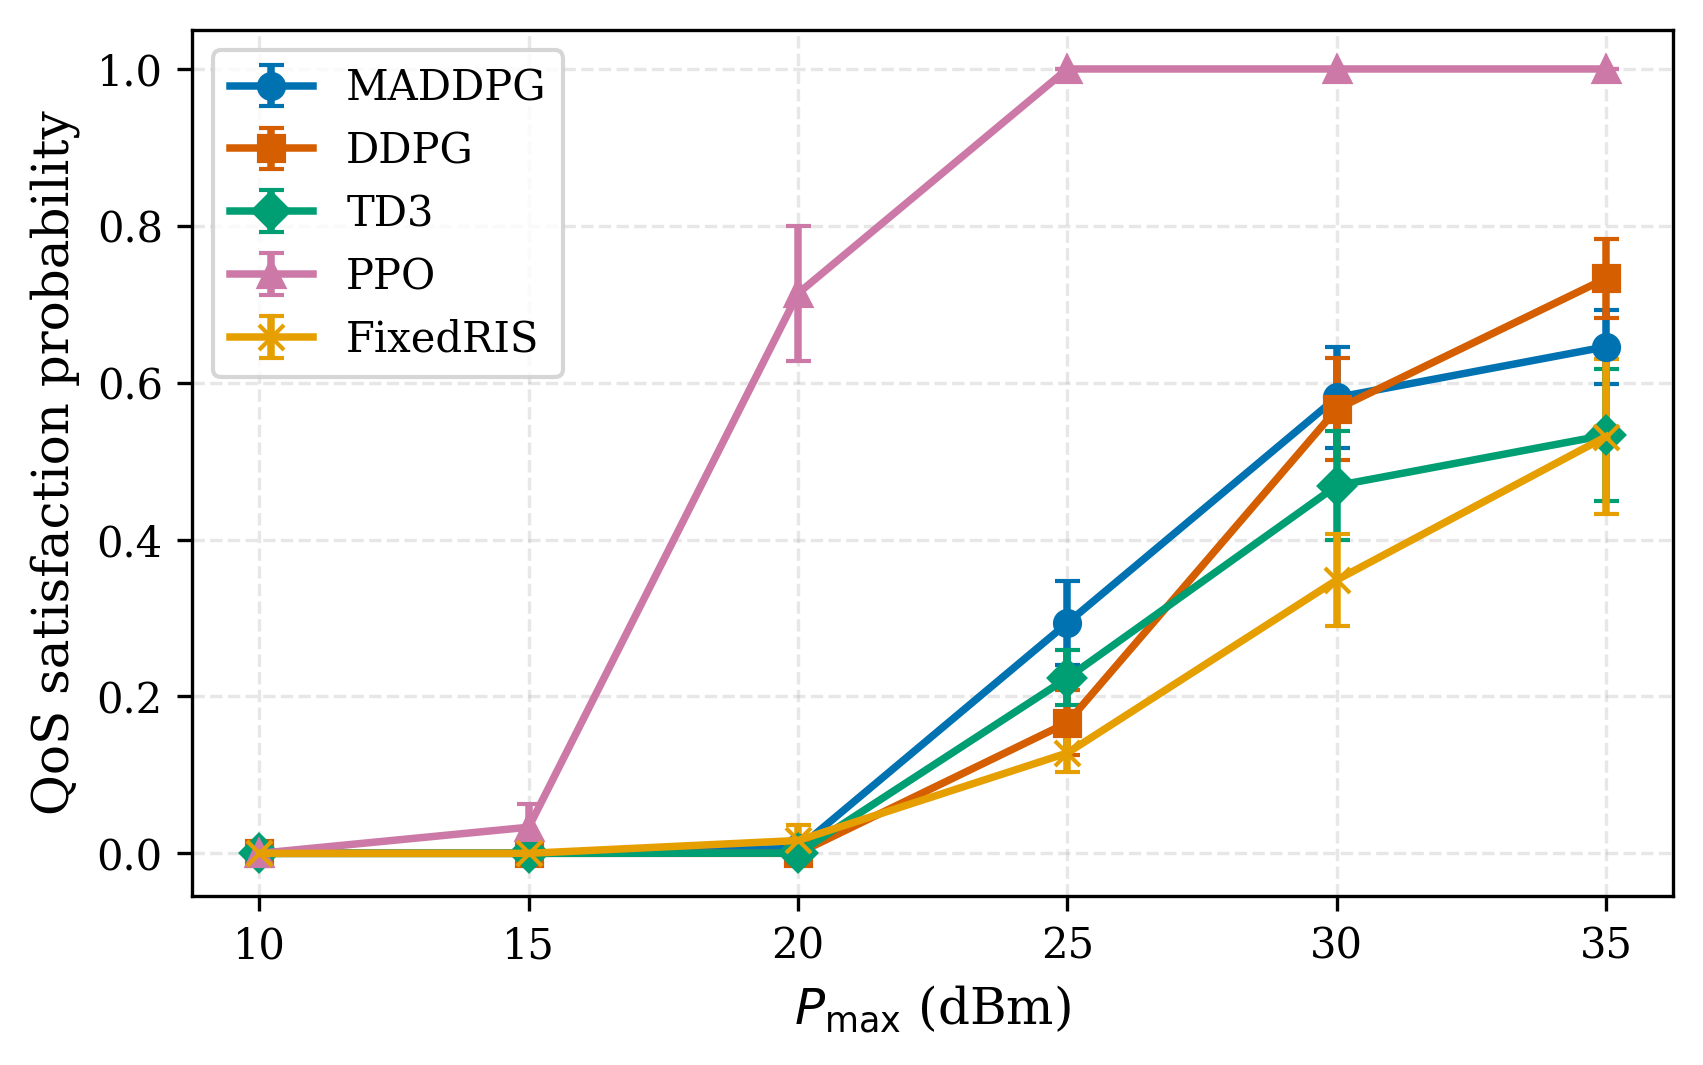

In [7]:
print("\n========== Sweep: Sum-rate & QoS vs Pmax (Đa Seed CI) ==========")
agents = {algo: info["agent"] for algo, info in trained_main.items()}
obs_norms = {algo: info["obs_norm"] for algo, info in trained_main.items()}
if "MADDPG" in trained_main:
    agents["FixedRIS"] = trained_main["MADDPG"]["agent"]
    obs_norms["FixedRIS"] = trained_main["MADDPG"]["obs_norm"]

sr_vs_p = sweep_power(agents, obs_norms, cfg)

# Vẽ đồ thị sum-rate vs power
plot_metric_vs_x(cfg["evaluation"]["power_sweep_dbm"], sr_vs_p,
                 xlabel="$P_{\\max}$ (dBm)", ylabel="Avg. sum-rate (b/s/Hz)",
                 out_dir=fig_dir, name="sumrate_vs_power")

# QoS sub-plot vs power
qos_vs_p = {algo: {"x": cfg["evaluation"]["power_sweep_dbm"],
                   "mean": sr_vs_p[algo]["qos_mean"],
                   "ci":   sr_vs_p[algo]["qos_ci"]} for algo in sr_vs_p}
plot_metric_vs_x(cfg["evaluation"]["power_sweep_dbm"], qos_vs_p,
                 xlabel="$P_{\\max}$ (dBm)", ylabel="QoS satisfaction probability",
                 out_dir=fig_dir, name="qos_vs_power")

# Lưu bảng dữ liệu CSV
df_sweep_p = pd.DataFrame({"Pmax_dBm": cfg["evaluation"]["power_sweep_dbm"],
              **{f"{a}_sr_mean": sr_vs_p[a]["mean"] for a in sr_vs_p},
              **{f"{a}_sr_ci":   sr_vs_p[a]["ci"]   for a in sr_vs_p}})
df_sweep_p.to_csv(os.path.join(tab_dir, "sumrate_vs_power.csv"), index=False)

# Hiển thị ảnh trực tiếp
print("--- Đồ thị Sum-rate vs BS Transmit Power ---")
display(Image(filename=os.path.join(fig_dir, "sumrate_vs_power.png")))
print("--- Đồ thị QoS Satisfaction vs BS Transmit Power ---")
display(Image(filename=os.path.join(fig_dir, "qos_vs_power.png")))

### 8. Đánh giá Xác suất QoS (QoS satisfaction probability) và Độ trễ suy luận (Inference Latency)
- **QoS Satisfaction Bar Plot**: Hiển thị khả năng đáp ứng ràng buộc QoS của các thuật toán.
- **Latency Bar Plot**: So sánh thời gian xử lý ra quyết định (độ trễ tính toán) của các tác tử, rất quan trọng đối với các bài toán thời gian thực.


========== QoS satisfaction (Đa Seed Bars) ==========

========== Độ trễ suy luận (Inference Latency) ==========
--- Xác suất đáp ứng QoS (Có khoảng tin cậy 95%) ---


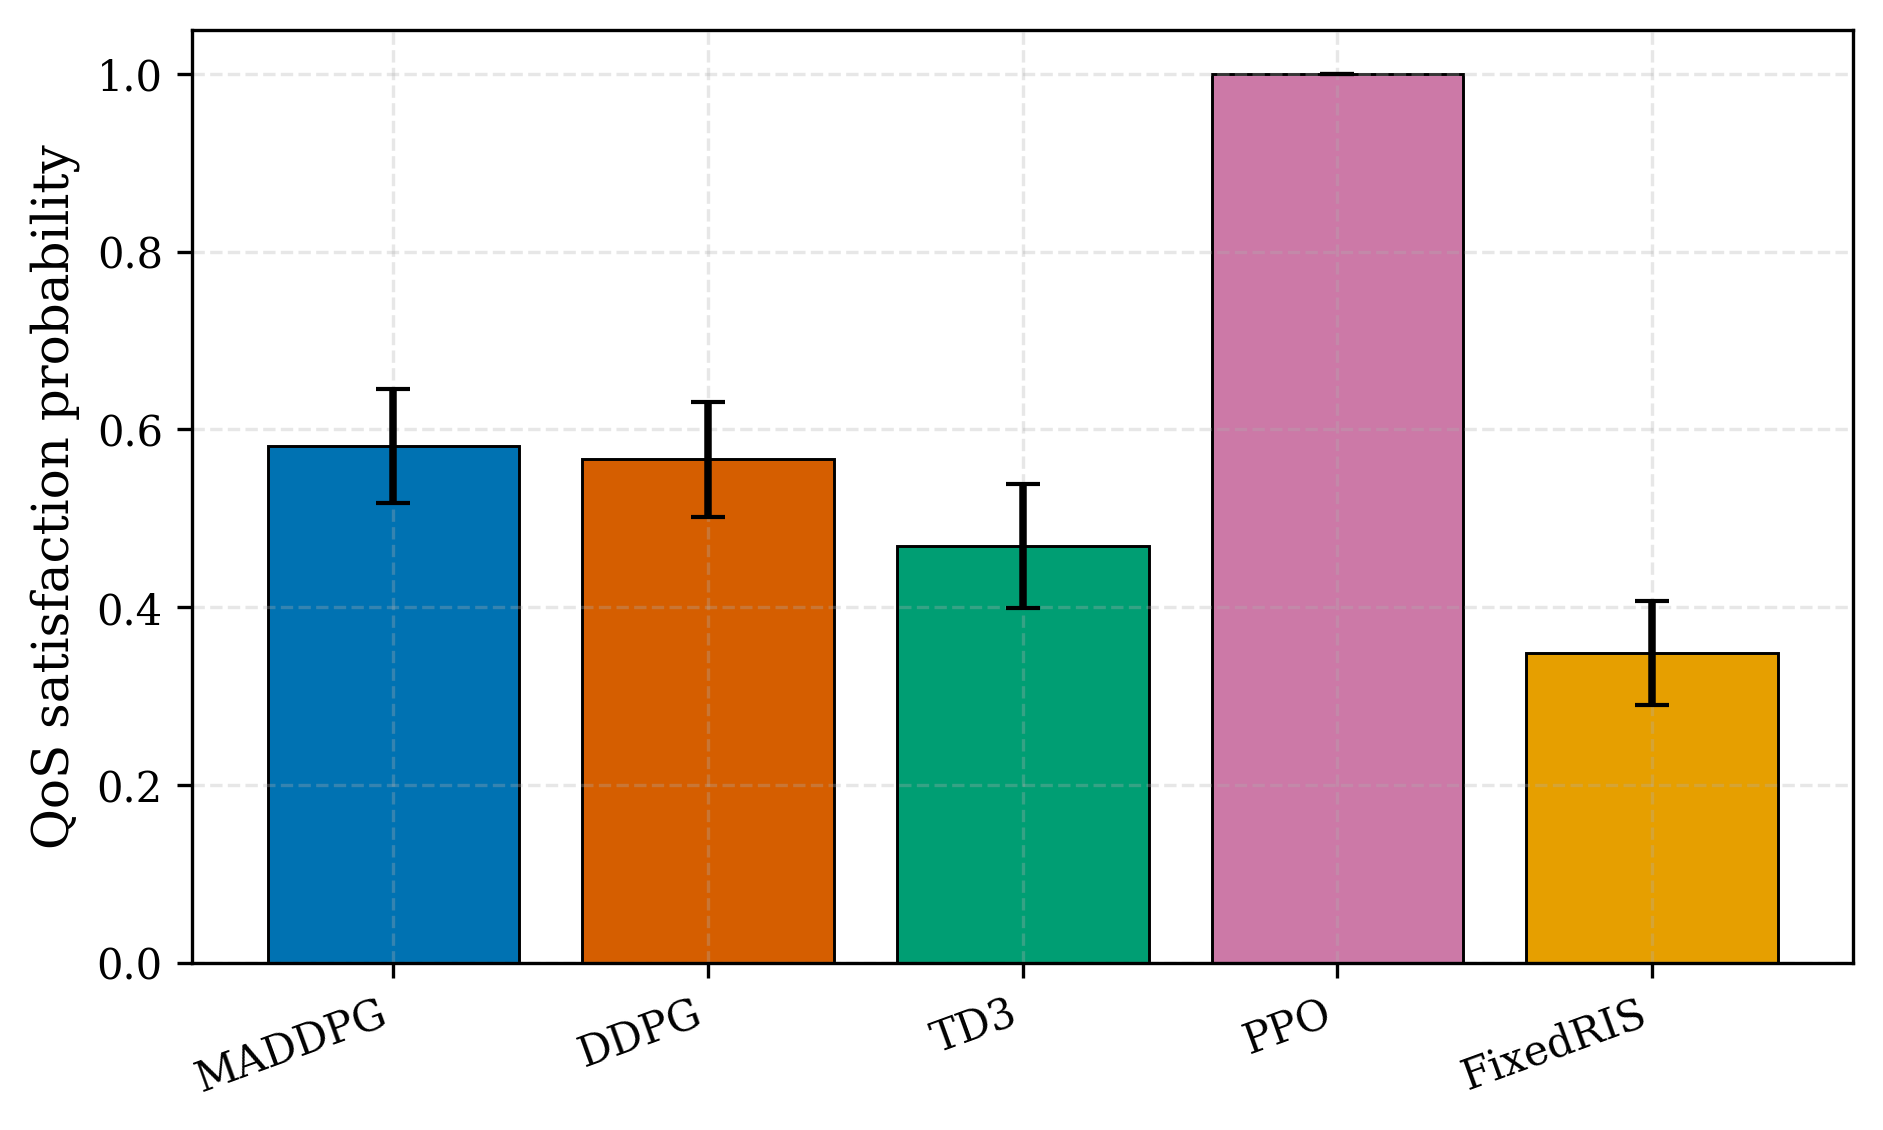

--- Độ trễ suy luận (ms / bước ra quyết định) ---


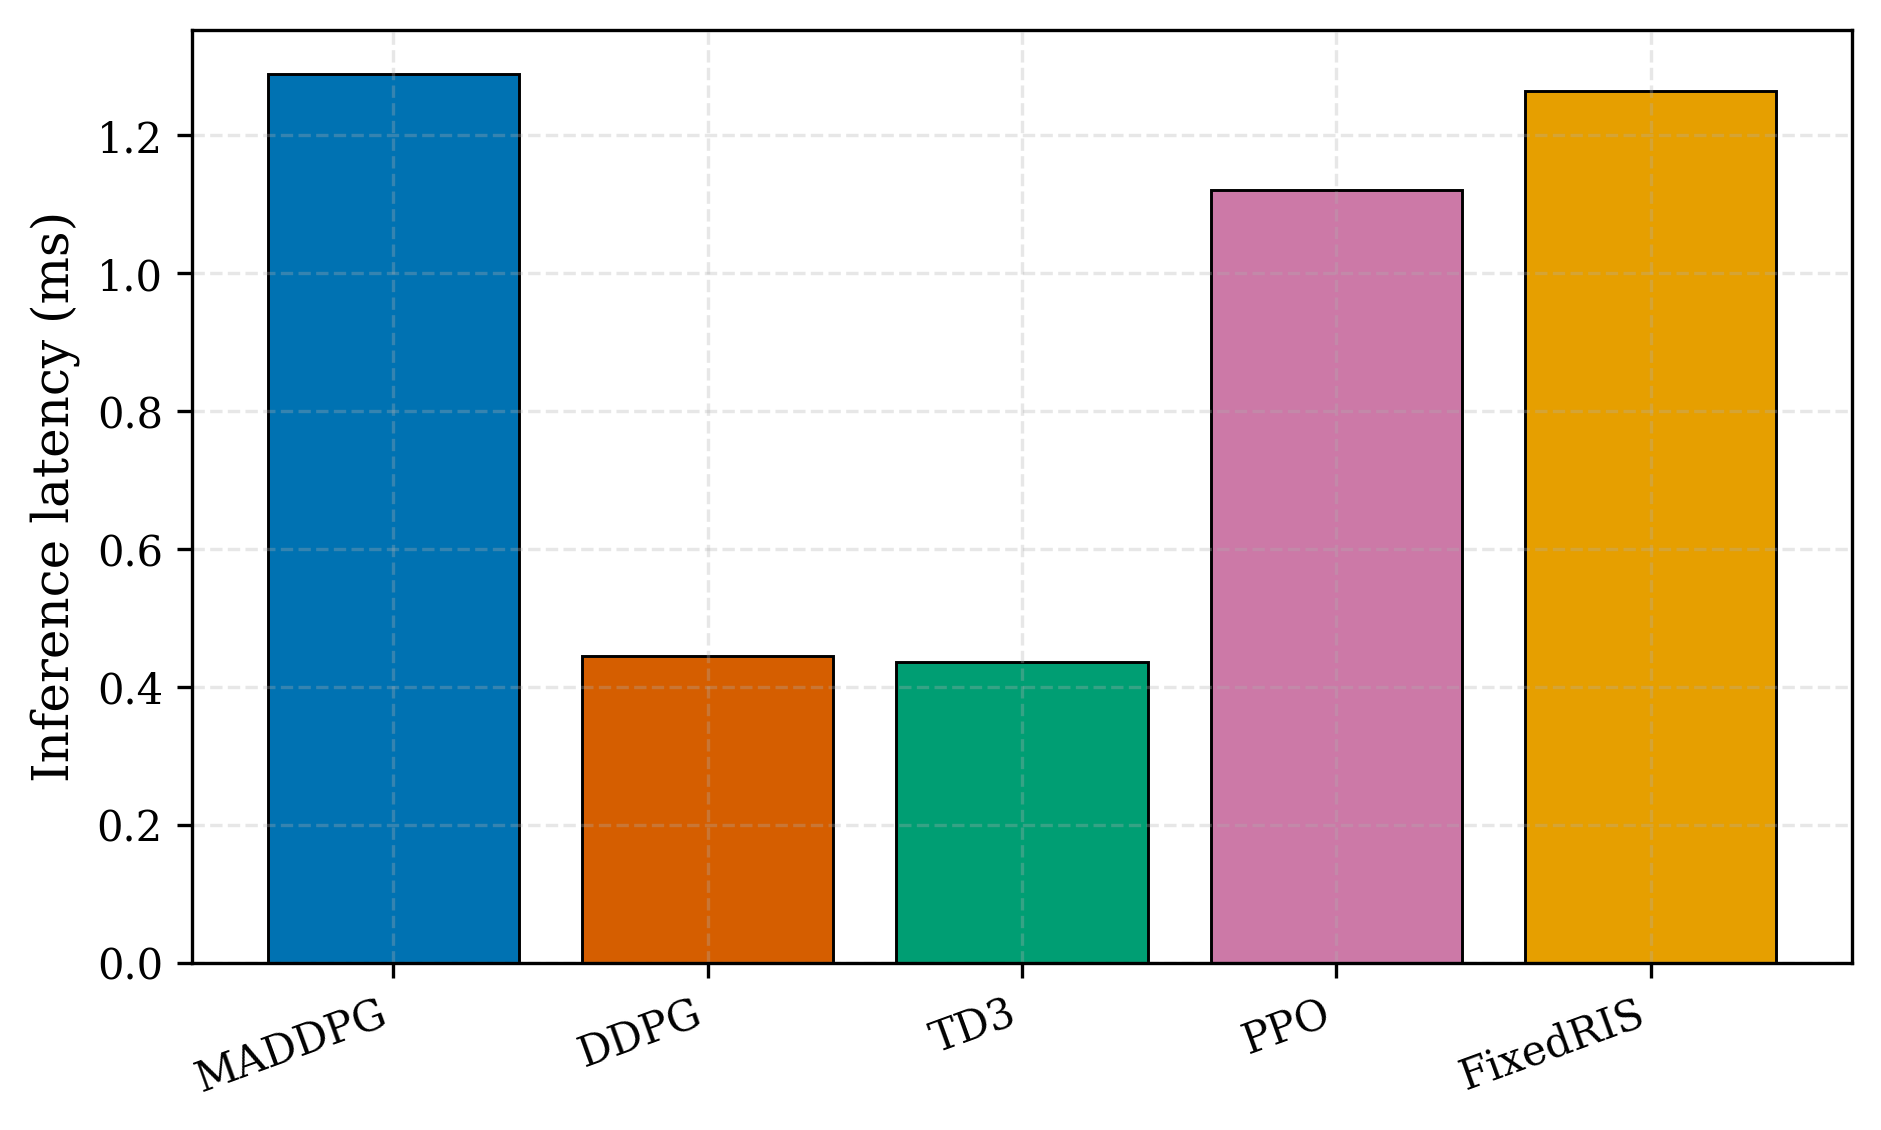

In [8]:
print("\n========== QoS satisfaction (Đa Seed Bars) ==========")
qos = qos_satisfaction(agents, obs_norms, cfg)
plot_bar(list(qos.keys()), {k: v["mean"] for k, v in qos.items()},
         out_dir=fig_dir, name="qos_probability",
         ylabel="QoS satisfaction probability",
         ci={k: v["ci"] for k, v in qos.items()})

print("\n========== Độ trễ suy luận (Inference Latency) ==========")
lat = latency_benchmark(agents, obs_norms, cfg)
plot_bar(list(lat.keys()), lat, out_dir=fig_dir, name="latency",
         ylabel="Inference latency (ms)")

# Hiển thị ảnh trực tiếp
print("--- Xác suất đáp ứng QoS (Có khoảng tin cậy 95%) ---")
display(Image(filename=os.path.join(fig_dir, "qos_probability.png")))
print("--- Độ trễ suy luận (ms / bước ra quyết định) ---")
display(Image(filename=os.path.join(fig_dir, "latency.png")))

### 9. Nghiên cứu Loại bỏ (Ablation Study) cho cấu phần STAR-RIS và Phân bổ công suất BS
Ablation study khảo sát hiệu năng dưới các cấu hình loại bỏ khác nhau (tổng cộng 7 cells):
1. **Learned**: Thuật toán đề xuất hoàn chỉnh (học cả công suất BS và pha STAR-RIS).
2. **AnalyticalRIS**: Học công suất BS kết hợp với giải thuật pha RIS giải tích.
3. **FixedRIS**: Học công suất BS kết hợp pha RIS cố định.
4. **RandomRIS**: Học công suất BS kết hợp pha RIS ngẫu nhiên.
5. **equal_power_learned**: Công suất BS phân bổ đều, học pha RIS.
6. **equal_power_fixed**: Công suất BS phân bổ đều, pha RIS cố định.

Các kết quả sẽ được hiển thị dưới dạng biểu đồ cột và bảng thống kê chi tiết.


========== Nghiên cứu loại bỏ (Ablation Study - 7 cells) ==========
--- Hiệu năng Sum-rate của các cấu hình Ablation ---


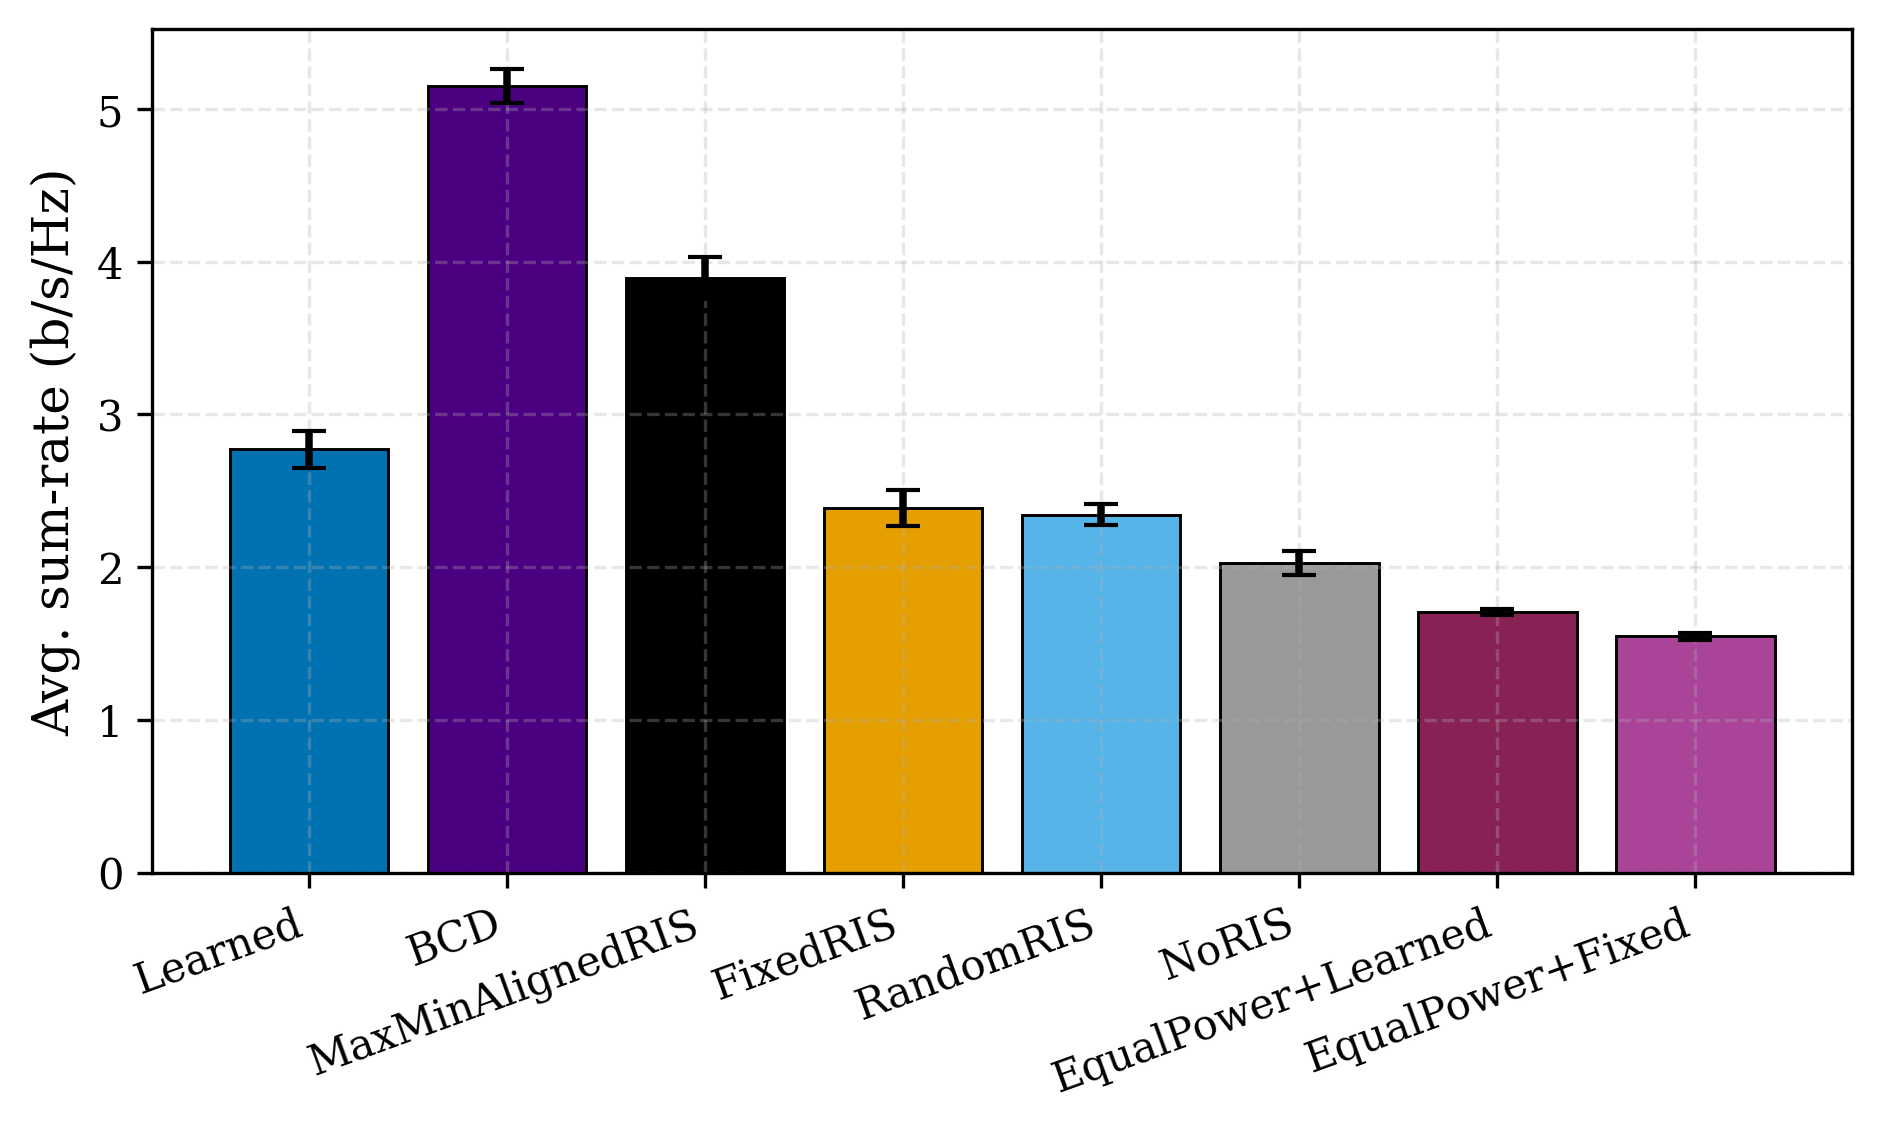

--- Xác suất QoS của các cấu hình Ablation ---


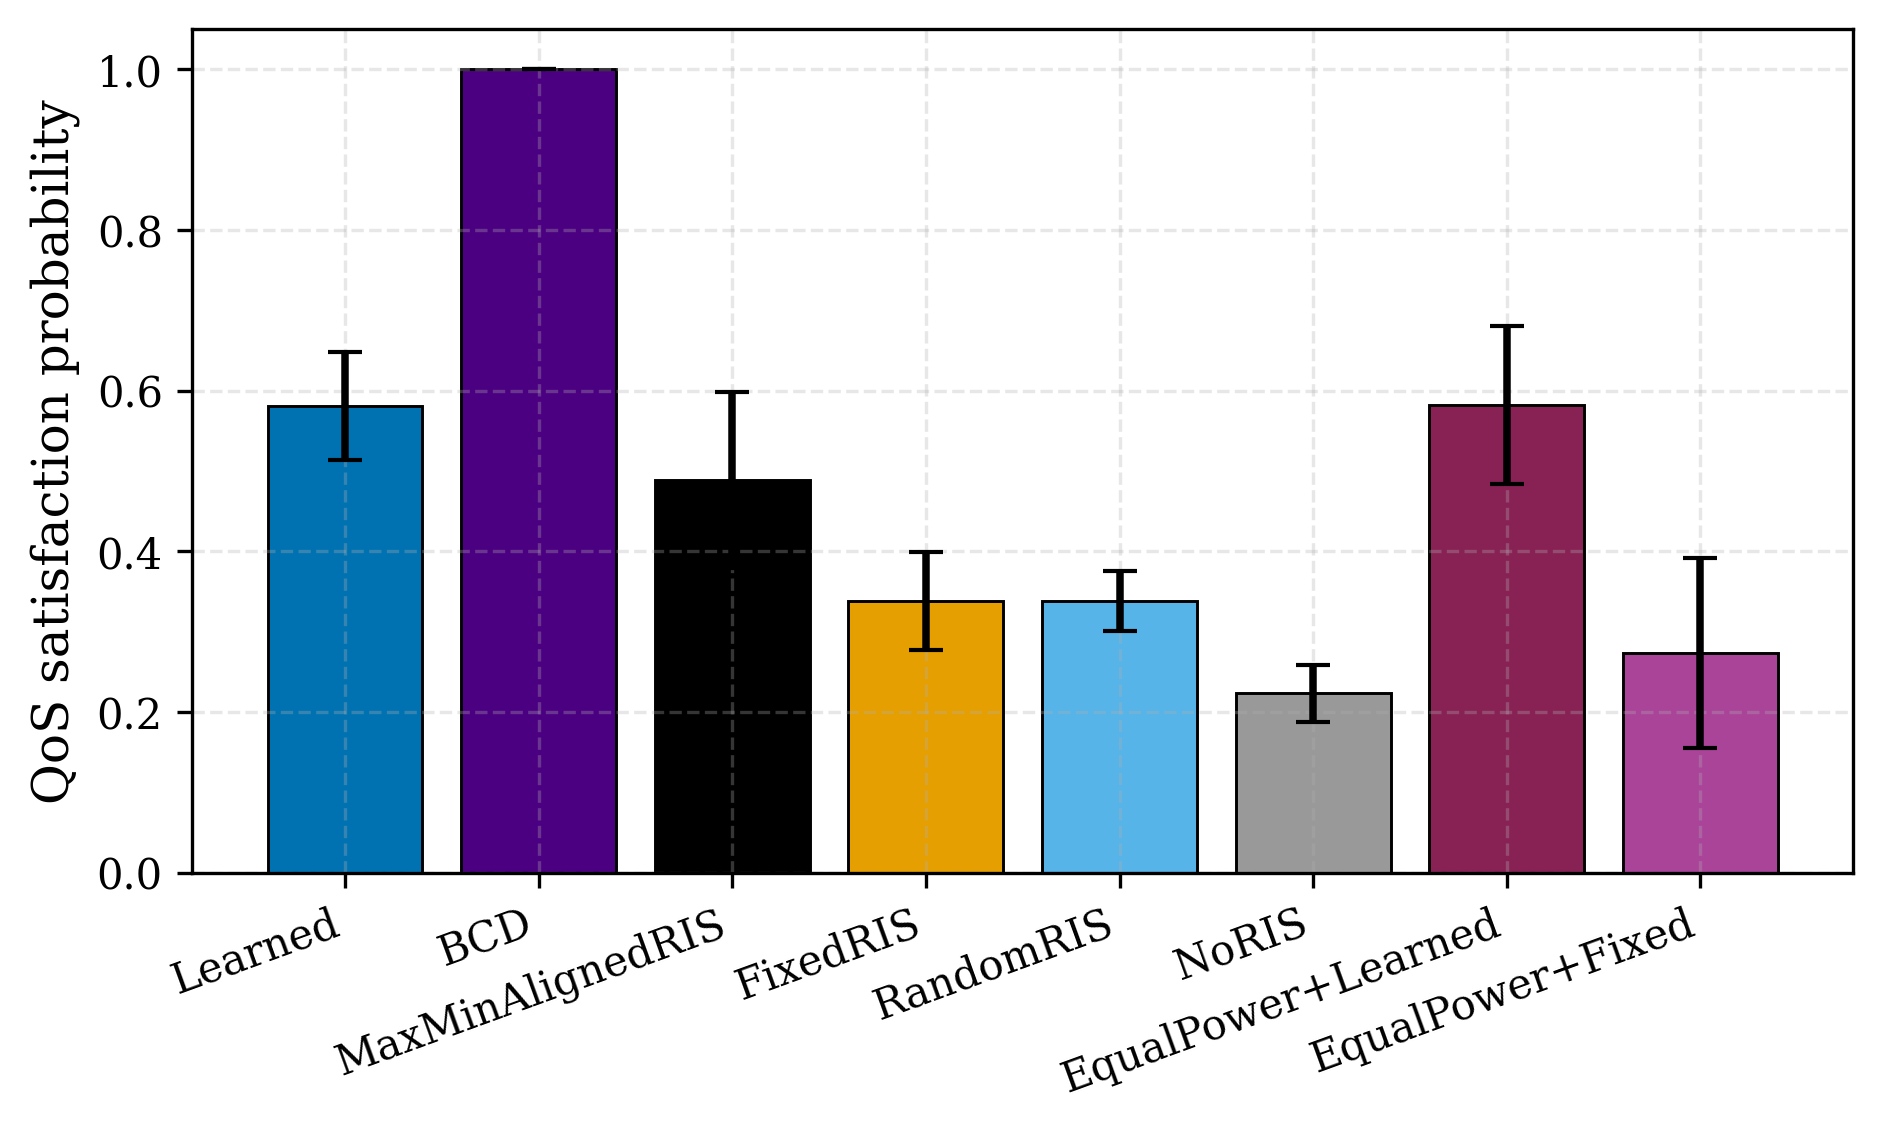


--- Bảng kết quả Ablation Study ---


,Cell,SumRate_mean,SumRate_CI95,QoS_mean,QoS_CI95,RateCommon,|h_eff_T|,PhaseEntropy_T,P_c/Pmax
0,Learned,2.771953,0.119764,0.581200,0.066897,1.151970,0.000002,2.514251,0.755121
1,BCD,5.147698,0.111227,1.000000,0.000000,3.711474,0.000009,2.502852,0.950000
2,MaxMinAlignedRIS,3.894197,0.136622,0.488533,0.109403,1.767686,0.000007,2.502852,0.671058
3,FixedRIS,2.387454,0.119660,0.337733,0.061096,0.760699,0.000002,0.000000,0.732730
4,RandomRIS,2.344895,0.067486,0.338133,0.037580,0.757821,0.000002,2.503972,0.746874
5,NoRIS,2.028047,0.077150,0.223200,0.035470,0.488458,0.000001,0.000000,0.741594
6,EqualPower+Learned,1.703876,0.019883,0.582400,0.098553,0.213145,0.000002,2.510251,0.200000
7,EqualPower+Fixed,1.547558,0.022647,0.273333,0.118500,0.145368,0.000002,0.000000,0.200000


In [9]:
if "MADDPG" in trained_main:
    print("\n========== Nghiên cứu loại bỏ (Ablation Study - 7 cells) ==========")
    maddpg_lam = trained_main["MADDPG"].get("trained_qos_lambda")
    abl = ablation_study(trained_main["MADDPG"]["agent"],
                         trained_main["MADDPG"]["obs_norm"], cfg,
                         qos_lambda=maddpg_lam)
    
    labels = list(abl.keys())
    means = {k: abl[k]["sum_rate_mean"] for k in labels}
    cis = {k: abl[k]["sum_rate_ci"] for k in labels}
    
    plot_bar(labels, means, out_dir=fig_dir, name="ablation",
             ylabel="Avg. sum-rate (b/s/Hz)", ci=cis)
    
    plot_bar(labels, {k: abl[k]["qos_mean"] for k in labels},
             out_dir=fig_dir, name="ablation_qos",
             ylabel="QoS satisfaction probability",
             ci={k: abl[k]["qos_ci"] for k in labels})
    
    # Tạo DataFrame chi tiết
    df_abl = pd.DataFrame({
        "Cell": labels,
        "SumRate_mean": [abl[k]["sum_rate_mean"] for k in labels],
        "SumRate_CI95": [abl[k]["sum_rate_ci"] for k in labels],
        "QoS_mean":     [abl[k]["qos_mean"] for k in labels],
        "QoS_CI95":     [abl[k]["qos_ci"] for k in labels],
        "RateCommon":   [abl[k]["rate_common"] for k in labels],
        "|h_eff_T|":    [abl[k]["h_eff_abs_T"] for k in labels],
        "PhaseEntropy_T":[abl[k]["phase_entropy_T"] for k in labels],
        "P_c/Pmax":     [abl[k]["common_power_frac"] for k in labels],
    })
    df_abl.to_csv(os.path.join(tab_dir, "ablation.csv"), index=False)
    
    # Hiển thị ảnh và bảng kết quả
    print("--- Hiệu năng Sum-rate của các cấu hình Ablation ---")
    display(Image(filename=os.path.join(fig_dir, "ablation.png")))
    print("--- Xác suất QoS của các cấu hình Ablation ---")
    display(Image(filename=os.path.join(fig_dir, "ablation_qos.png")))
    print("\n--- Bảng kết quả Ablation Study ---")
    display(df_abl)
else:
    print("MADDPG không được huấn luyện, bỏ qua Ablation Study.")

### 10. So sánh Hiệu năng giữa các Thuật toán & Kiểm định ý nghĩa thống kê (Welch's t-test)
Đánh giá chi tiết khả năng vận hành của từng thuật toán qua 12 training seeds × 5 evaluation seeds.
Sử dụng kiểm định thống kê Welch's t-test trên phân phối phần thưởng (returns) tích lũy của các hạt seed khác nhau giữa MADDPG và các baseline để kiểm chứng xem sự cải thiện hiệu năng có mang ý nghĩa thống kê ($p < 0.05$) hay không.

In [10]:
print("\n========== So sánh hiệu năng các thuật toán (Đa Seed) ==========")
rows = []
pareto_points = {}
per_seed_returns_per_algo = {}

for algo, runs in trained.items():
    run_rets, run_srs, run_qoss, run_lats, run_lams = [], [], [], [], []
    run_rc, run_htabs, run_pent, run_cfrac = [], [], [], []
    for info in runs:
        lam = info.get("trained_qos_lambda")
        m_run = _eval_multi_seed(info["agent"], algo, info["obs_norm"], cfg,
                                 cfg["evaluation"]["seeds"], qos_lambda=lam)
        run_rets.append(m_run["return_mean"])
        run_srs.append(m_run["sum_rate_mean"])
        run_qoss.append(m_run["qos_mean"])
        run_lats.append(m_run["latency_ms_mean"])
        run_rc.append(m_run["rate_common_mean"])
        run_htabs.append(m_run["h_eff_abs_T_mean"])
        run_pent.append(m_run["phase_entropy_T_mean"])
        run_cfrac.append(m_run["common_power_frac_mean"])
        run_lams.append(lam if lam is not None else float("nan"))
        
    # Tính khoảng tin cậy trên các seed huấn luyện (Student-t 95% CI)
    ret_m, ret_ci, _ = confidence_interval(np.array(run_rets))
    sr_m, sr_ci, _   = confidence_interval(np.array(run_srs))
    q_m, q_ci, _     = confidence_interval(np.array(run_qoss))
    lat_m = float(np.mean(run_lats))
    
    rows.append({"Algorithm": algo,
                 "Return": ret_m, "Return_CI": ret_ci,
                 "SumRate": sr_m, "SumRate_CI": sr_ci,
                 "QoS_prob": q_m, "QoS_CI": q_ci,
                 "RateCommon": float(np.mean(run_rc)),
                 "|h_eff_T|":   float(np.mean(run_htabs)),
                 "PhaseEntropy_T": float(np.mean(run_pent)),
                 "P_c/Pmax":    float(np.mean(run_cfrac)),
                 "Latency_ms":  lat_m,
                 "trained_lambda_mean": float(np.nanmean(run_lams)),
                 "N_train_seeds": len(runs)})
    pareto_points[algo] = {"sum_rate_mean": sr_m, "sum_rate_ci": sr_ci,
                           "qos_mean": q_m, "qos_ci": q_ci}
    per_seed_returns_per_algo[algo] = run_rets

df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(os.path.join(tab_dir, "algorithm_comparison.csv"), index=False)
print("\n--- Bảng so sánh thuật toán (12 seeds) ---")
display(df_cmp)

# Kiểm định thống kê Welch t-test
print("\n========== Welch's t-test (so với MADDPG) ==========")
if "MADDPG" in trained:
    m_returns = np.array(per_seed_returns_per_algo["MADDPG"], dtype=float)
    sig_rows = []
    for algo, vec in per_seed_returns_per_algo.items():
        if algo == "MADDPG":
            continue
        r = np.array(vec, dtype=float)
        p = welch_ttest_p(m_returns, r)
        sig_rows.append({"Comparison": f"MADDPG vs {algo}",
                         "delta_mean_return": float(m_returns.mean() - r.mean()),
                         "p_value": p,
                         "significant_5pct": p < 0.05,
                         "N_seeds_per_algo": len(training_seeds)})
    df_sig = pd.DataFrame(sig_rows)
    df_sig.to_csv(os.path.join(tab_dir, "significance.csv"), index=False)
    display(df_sig)
else:
    print("MADDPG không khả dụng cho Welch t-test.")


========== So sánh hiệu năng các thuật toán (Đa Seed) ==========

--- Bảng so sánh thuật toán (12 seeds) ---


,Algorithm,Return,Return_CI,SumRate,SumRate_CI,QoS_prob,QoS_CI,RateCommon,|h_eff_T|,PhaseEntropy_T,P_c/Pmax,Latency_ms,trained_lambda_mean,N_train_seeds
0,MADDPG,1.743545,0.539838,2.793479,0.076072,0.444378,0.057657,1.137963,0.000002,2.502058,0.750048,1.348161,11.266749,12
1,DDPG,2.082610,0.362838,1.765916,0.025507,0.490211,0.073989,0.234148,0.000003,2.496630,0.199339,0.504931,13.907229,12
2,TD3,1.184113,0.392251,2.714911,0.155156,0.322511,0.071546,1.028043,0.000003,2.506991,0.633487,0.501230,14.833342,12
3,PPO,3.311248,0.007776,2.165164,0.021027,0.998900,0.001652,0.531055,0.000007,2.494982,0.315992,1.186548,15.000000,12



========== Welch's t-test (so với MADDPG) ==========


,Comparison,delta_mean_return,p_value,significant_5pct,N_seeds_per_algo
0,MADDPG vs DDPG,-0.339066,0.259667,False,12
1,MADDPG vs TD3,0.559432,0.076445,False,12
2,MADDPG vs PPO,-1.567704,0.000046,True,12


### 11. So sánh Khả năng thuần túy của tác tử tại $\lambda = 0$ và Đồ thị Pareto
- So sánh $\lambda = 0$: Loại bỏ thành phần phạt QoS để đánh giá trực tiếp khả năng truyền tin thuần túy của các thuật toán.
- Đồ thị Pareto: Phân tích sự đánh đổi (trade-off) giữa Tốc độ truyền tổng cộng (Sum-rate) và Khả năng đáp ứng QoS.


========== So sánh thuật toán tại λ = 0 ==========


/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:54: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 0.0000 to 0.3000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(qos_lambda_override)



--- Bảng so sánh tại λ = 0 ---


,Algorithm,Return_l0,Return_l0_CI,SumRate_l0,SumRate_l0_CI,QoS_l0,QoS_l0_CI
0,MADDPG,2.986304,0.083995,2.790055,0.077318,0.441167,0.054520
1,DDPG,2.792503,0.069980,1.765172,0.025620,0.490300,0.073849
2,TD3,2.861661,0.113748,2.712346,0.154579,0.322922,0.071078
3,PPO,3.311249,0.007776,2.165164,0.021027,0.998900,0.001652



========== Đồ thị tối ưu Pareto (Sum-rate vs QoS) ==========


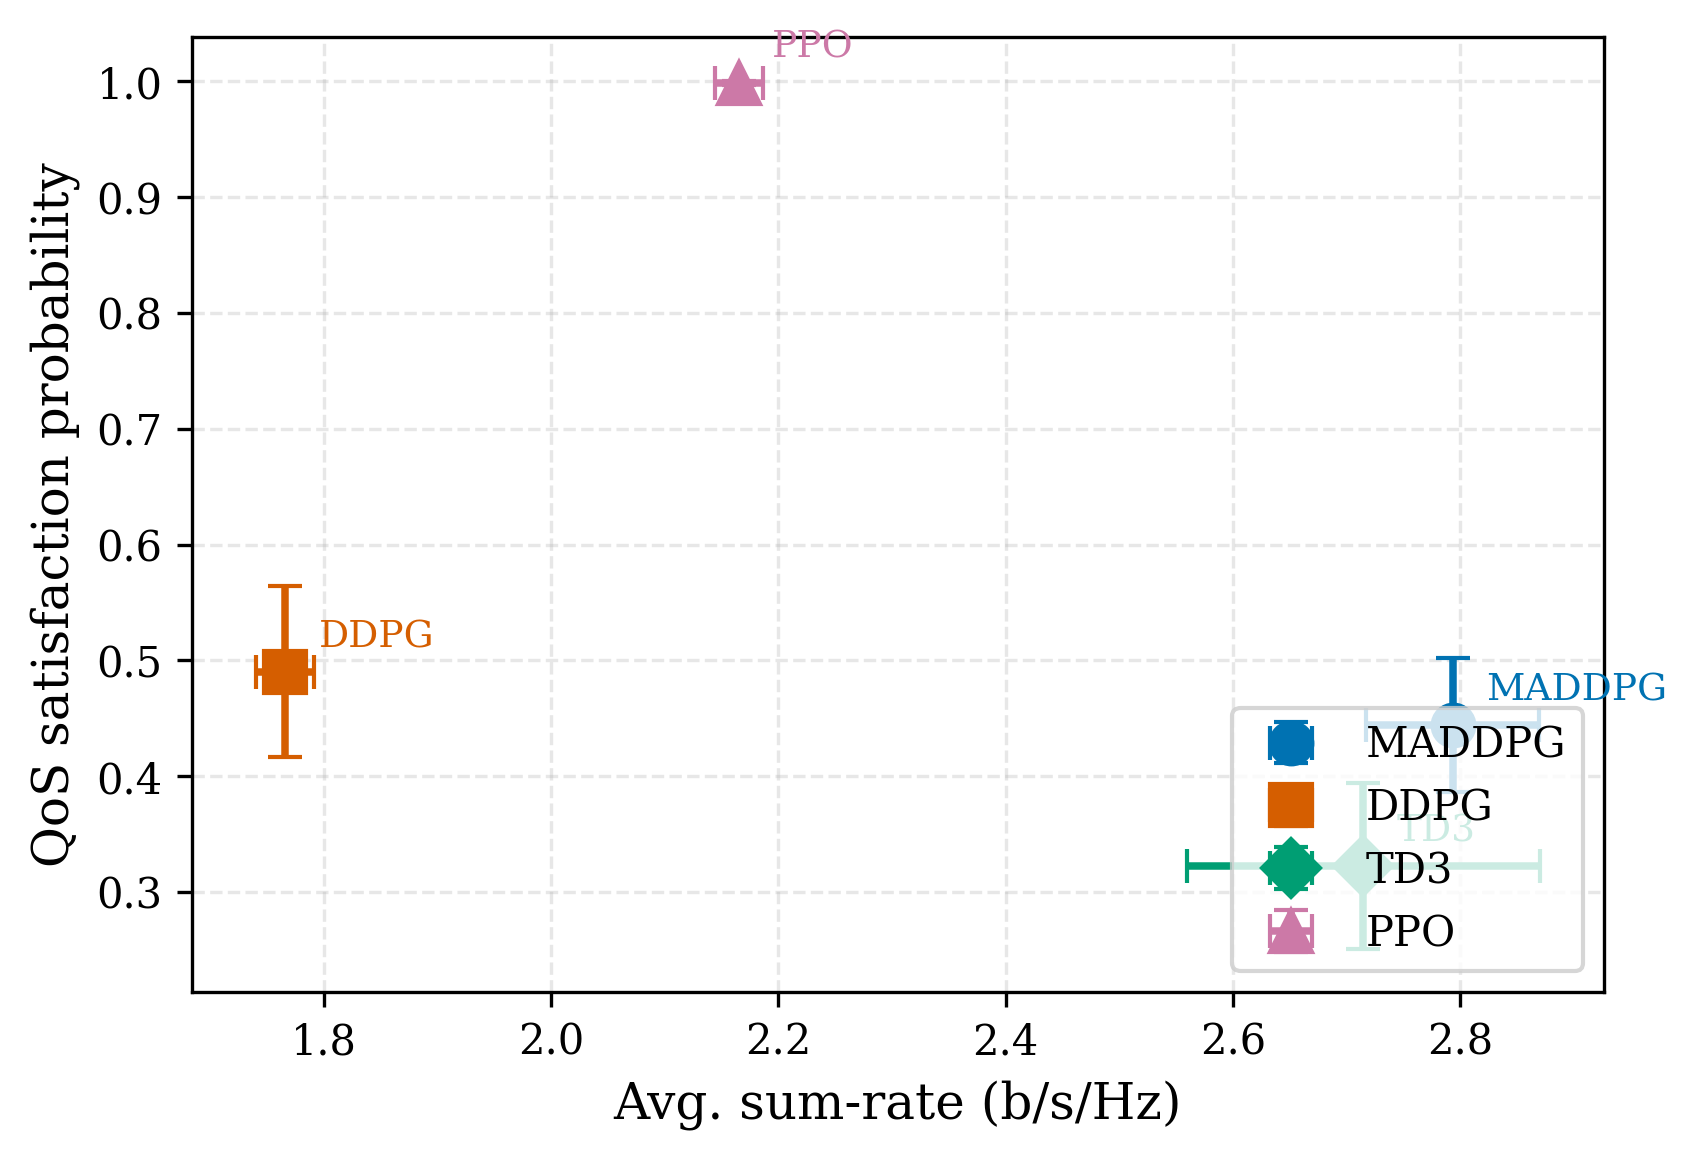

In [11]:
print("\n========== So sánh thuật toán tại λ = 0 ==========")
rows_l0 = []
for algo, runs in trained.items():
    rs, ss, qs = [], [], []
    for info in runs:
        m_run = _eval_multi_seed(info["agent"], algo, info["obs_norm"], cfg,
                                 cfg["evaluation"]["seeds"], qos_lambda=0.0)
        rs.append(m_run["return_mean"])
        ss.append(m_run["sum_rate_mean"])
        qs.append(m_run["qos_mean"])
    r_m, r_ci, _ = confidence_interval(np.array(rs))
    s_m, s_ci, _ = confidence_interval(np.array(ss))
    q_m_l0, q_ci_l0, _ = confidence_interval(np.array(qs))
    rows_l0.append({"Algorithm": algo,
                    "Return_l0": r_m, "Return_l0_CI": r_ci,
                    "SumRate_l0": s_m, "SumRate_l0_CI": s_ci,
                    "QoS_l0": q_m_l0, "QoS_l0_CI": q_ci_l0})

df_cmp_l0 = pd.DataFrame(rows_l0)
df_cmp_l0.to_csv(os.path.join(tab_dir, "algorithm_comparison_lambda0.csv"), index=False)
print("\n--- Bảng so sánh tại λ = 0 ---")
display(df_cmp_l0)

print("\n========== Đồ thị tối ưu Pareto (Sum-rate vs QoS) ==========")
plot_pareto(pareto_points, out_dir=fig_dir, name="pareto_sr_vs_qos")

# Hiển thị đồ thị Pareto trực tiếp
display(Image(filename=os.path.join(fig_dir, "pareto_sr_vs_qos.png")))

### 12. Tạo Báo cáo Kết quả Tóm tắt (`results_summary.md`)
Hàm này tự động ghi lại báo cáo tổng quan kết quả huấn luyện đa seed vào file `results_summary.md` để người dùng dễ dàng theo dõi hiệu năng hệ thống.

In [12]:
from main import _write_report

report_path = os.path.join(out_root, "results_summary.md")
_write_report(report_path, cfg, df_cmp, sr_vs_p, qos, lat,
              abl if "MADDPG" in trained else None)

print(f"Báo cáo kết quả đã được ghi vào: {report_path}")
print("\n--- Nội dung báo cáo tóm tắt ---")
with open(report_path, "r", encoding="utf-8") as f:
    print(f.read())

Báo cáo kết quả đã được ghi vào: /kaggle/working/results_summary.md

--- Nội dung báo cáo tóm tắt ---
# Results Summary — DRL Resource Allocation in STAR-RIS Assisted RSMA Networks
## 1. System Setup
- SISO downlink, K = 4 users (K_R = 3), N = 32 STAR-RIS elements (ES mode).
- P_max = 30.0 dBm, noise = -90.0 dBm, per-user QoS = 0.3 b/s/Hz, T-blockage = 25.0 dB.
- Reward: quadratic QoS with adaptive Lagrangian λ (init 1.0, target satisfaction 0.5).
## 2. Algorithm Comparison (5-seed deterministic eval)
```
Algorithm   Return  Return_CI  SumRate  SumRate_CI  QoS_prob   QoS_CI  RateCommon  |h_eff_T|  PhaseEntropy_T  P_c/Pmax  Latency_ms  trained_lambda_mean  N_train_seeds
   MADDPG 1.743545   0.539838 2.793479    0.076072  0.444378 0.057657    1.137963   0.000002        2.502058  0.750048    1.348161            11.266749             12
     DDPG 2.082610   0.362838 1.765916    0.025507  0.490211 0.073989    0.234148   0.000003        2.496630  0.199339    0.504931            13.907229    